#Analysis of Prostate Cancer Survival

#####Gourav Velma
---

##INTRODUCTION

This tutorial is designed to guide users through the complete data science pipeline, providing a comprehensive walkthrough of the process from start to finish. The tutorial will cover key stages including data collection and data processing to ensure the dataset is clean and structured for analysis. It will then go into exploratory data analysis (EDA) to uncover patterns, relationships, and trends in the data.

Next, the tutorial will incorporate hypothesis testing and machine learning to perform predictive analysis, demonstrating the practical application of these techniques. Finally, it will provide analysis results to convey the insights learned throughout the tutorial.

Analyzing prostate cancer survival is crucial as it helps improve patient outcomes by identifying factors influencing survival rates and informing personalized treatment strategies. Prostate cancer is one of the most common cancers among men, and understanding survival trends can aid early diagnosis, optimize medical interventions, and allocate healthcare resources effectively. Moreover, survival analysis provides valuable insights into the impact of clinical, genetic, and lifestyle factors, supporting advancements in research and enhancing the overall quality of care for patients. Learn more about prostate cancer [here](https://www.cancer.gov/types/prostate)


##DATA COLLECTION

In the data collection stage, the primary goal is to acquire the dataset and perform an initial exploration to understand its structure and contents. This involves loading the data into the working environment, verifying its format, and obtaining a preliminary overview of its attributes, such as column names and variable types. These steps ensure that the dataset is successfully collected, properly formatted, and ready for the subsequent stages of the data science pipeline.

Health data is highly sensitive, and working with an accurate and reliable dataset is essential. For this analysis, we obtained our dataset from [cBioPortal](https://www.cbioportal.org/), a trusted platform known for providing comprehensive cancer genomics and large-scale cancer genomics datasets.

In this project, we will be using the Python programming language along with tools like iPython and Jupyter Notebook for development. Learn more about these resources at[iPython](https://ipython.org/) and [Jupyter Notebook](https://jupyter.org/) and


####Imports

As with any Python project, we need to import essential libraries. Below are some of the key libraries that will be used throughout this tutorial.

In this project, we will use [Pandas](https://pandas.pydata.org/) for flexible and efficient data manipulation and [NumPy](https://numpy.org/) for fast numerical computations, especially when handling large datasets. These libraries are essential for transforming and managing data effectively.

In [1]:
import folium
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.svm import SVC
from scipy.stats import norm
from sklearn import linear_model
from IPython.display import HTML
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


warnings.filterwarnings("ignore")

###Reading the dataset


In [2]:
df = pd.read_csv("prostate_msk_2024_clinical_data.tsv", sep="\t")

In [3]:
df

,Study ID,Patient ID,Sample ID,Cancer Type,Cancer Type Detailed,Current Age,Impact TMB Percentile (Across All Tumor Types),Impact TMB Score,Impact TMB Percentile (Within Tumor Type),Ethnicity,...,Overall Survival Status,Progression Free Survival Status (months),Progression Free Survival Status,Race,Number of Samples Per Patient,Sample coverage,Sample Type,Somatic Status,Stage (Highest Recorded),Tumor Purity
0,prostate_msk_2024,P-0000140,P-0000140-T01-IM3,Prostate Cancer,Prostate Neuroendocrine Carcinoma,45.0,17.3,1.1,28.8,Non-Spanish; Non-Hispanic,...,1:DECEASED,NaN,NaN,White,1,629,Metastasis,Matched,Stage 4,60.0
1,prostate_msk_2024,P-0000197,P-0000197-T01-IM3,Prostate Cancer,Prostate Adenocarcinoma,80.0,44.1,3.3,69.1,Non-Spanish; Non-Hispanic,...,1:DECEASED,NaN,NaN,White,1,1188,Metastasis,Matched,Stage 4,30.0
2,prostate_msk_2024,P-0000318,P-0000318-T01-IM3,Prostate Cancer,Prostate Adenocarcinoma,67.0,44.1,3.3,69.1,Non-Spanish; Non-Hispanic,...,1:DECEASED,NaN,NaN,Patient Refused To Answer,1,782,Metastasis,Matched,Stage 4,60.0
3,prostate_msk_2024,P-0000373,P-0000373-T01-IM3,Prostate Cancer,Prostate Adenocarcinoma,58.0,17.3,1.1,28.8,Non-Spanish; Non-Hispanic,...,1:DECEASED,NaN,NaN,White,1,708,Metastasis,Matched,Stage 4,60.0
4,prostate_msk_2024,P-0000377,P-0000377-T03-IM3,Prostate Cancer,Prostate Adenocarcinoma,64.0,86.6,10.0,96.4,Non-Spanish; Non-Hispanic,...,1:DECEASED,NaN,NaN,White,1,805,Primary,Matched,Stage 4,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2255,prostate_msk_2024,P-0062755,P-0062755-T01-IM7,Prostate Cancer,Prostate Adenocarcinoma,63.0,18.0,1.6,29.6,Unknown whether Spanish or not,...,1:DECEASED,NaN,NaN,White,1,304,Primary,Matched,Stage 1-3,50.0
2256,prostate_msk_2024,P-0062762,P-0062762-T01-IM7,Prostate Cancer,Prostate Adenocarcinoma,76.0,30.0,2.5,48.4,Non-Spanish; Non-Hispanic,...,0:LIVING,NaN,NaN,White,1,548,Metastasis,Matched,Stage 1-3,10.0
2257,prostate_msk_2024,P-0062873,P-0062873-T01-IM7,Prostate Cancer,Prostate Adenocarcinoma,51.0,30.0,2.5,48.4,Non-Spanish; Non-Hispanic,...,0:LIVING,NaN,NaN,Black Or African American,1,269,Primary,Matched,Stage 4,50.0
2258,prostate_msk_2024,P-0062920,P-0062920-T01-IM7,Prostate Cancer,Prostate Adenocarcinoma,88.0,52.4,4.1,76.5,Non-Spanish; Non-Hispanic,...,0:LIVING,NaN,NaN,White,1,409,Primary,Matched,Stage 1-3,20.0


###Preliminary information about the dataset

In [4]:
print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (2260, 31)


In [5]:
print(df.dtypes)

Study ID                                           object
Patient ID                                         object
Sample ID                                          object
Cancer Type                                        object
Cancer Type Detailed                               object
Current Age                                       float64
Impact TMB Percentile (Across All Tumor Types)    float64
Impact TMB Score                                  float64
Impact TMB Percentile (Within Tumor Type)         float64
Ethnicity                                          object
Fraction Genome Altered                           float64
Gene Panel                                         object
Gleason Score, 1st Reported                       float64
Gleason Score, Highest Reported                   float64
Gleason Score Reported on Sample (NLP)            float64
MSI Comment                                        object
MSI Score                                         float64
MSI Type      

In [6]:
print(df.columns.tolist())

['Study ID', 'Patient ID', 'Sample ID', 'Cancer Type', 'Cancer Type Detailed', 'Current Age', 'Impact TMB Percentile (Across All Tumor Types)', 'Impact TMB Score', 'Impact TMB Percentile (Within Tumor Type)', 'Ethnicity', 'Fraction Genome Altered', 'Gene Panel', 'Gleason Score, 1st Reported', 'Gleason Score, Highest Reported', 'Gleason Score Reported on Sample (NLP)', 'MSI Comment', 'MSI Score', 'MSI Type', 'Mutation Count', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'Progression Free Survival Status (months)', 'Progression Free Survival Status', 'Race', 'Number of Samples Per Patient', 'Sample coverage', 'Sample Type', 'Somatic Status', 'Stage (Highest Recorded)', 'Tumor Purity']


##DATA PROCESSING

Data processing is a crucial step in the data science pipeline that involves preparing raw data for analysis. This step ensures the data is clean, structured, and suitable for deriving meaningful insights. Proper data processing minimizes errors, handles inconsistencies, and improves the accuracy of predictive models.

Tools like df.info() are used to examine the structure of the dataset, including column types and missing values, while df.describe() provides descriptive statistics, offering insights into the distribution, central tendency, and variability of numeric features. For a more comprehensive overview, df.describe(include="all") includes all column types, such as categorical data, allowing us to understand unique elements and summary statistics.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260 entries, 0 to 2259
Data columns (total 31 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Study ID                                        2260 non-null   object 
 1   Patient ID                                      2260 non-null   object 
 2   Sample ID                                       2260 non-null   object 
 3   Cancer Type                                     2260 non-null   object 
 4   Cancer Type Detailed                            2260 non-null   object 
 5   Current Age                                     2259 non-null   float64
 6   Impact TMB Percentile (Across All Tumor Types)  2210 non-null   float64
 7   Impact TMB Score                                2210 non-null   float64
 8   Impact TMB Percentile (Within Tumor Type)       2210 non-null   float64
 9   Ethnicity                                

Unique elements

In [8]:
summary_df = pd.DataFrame({
    'Column': df.columns,
    'Unique Elements': [df[col].nunique() for col in df.columns],
    'Top 5 Elements': [list(df[col].unique())[:5] for col in df.columns]
})

summary_df

,Column,Unique Elements,Top 5 Elements
0,Study ID,1,[prostate_msk_2024]
1,Patient ID,2257,"[P-0000140, P-0000197, P-0000318, P-0000373, P..."
2,Sample ID,2260,"[P-0000140-T01-IM3, P-0000197-T01-IM3, P-00003..."
3,Cancer Type,1,[Prostate Cancer]
4,Cancer Type Detailed,4,"[Prostate Neuroendocrine Carcinoma, Prostate A..."
5,Current Age,47,"[45.0, 80.0, 67.0, 58.0, 64.0]"
6,Impact TMB Percentile (Across All Tumor Types),116,"[17.3, 44.1, 86.6, nan, 74.4]"
7,Impact TMB Score,115,"[1.1, 3.3, 10.0, nan, 6.7]"
8,Impact TMB Percentile (Within Tumor Type),98,"[28.8, 69.1, 96.4, nan, 94.0]"
9,Ethnicity,10,"[Non-Spanish; Non-Hispanic, Spanish NOS; Hisp..."


In [9]:
df.describe()

,Current Age,Impact TMB Percentile (Across All Tumor Types),Impact TMB Score,Impact TMB Percentile (Within Tumor Type),Fraction Genome Altered,"Gleason Score, 1st Reported","Gleason Score, Highest Reported",Gleason Score Reported on Sample (NLP),MSI Score,Mutation Count,Overall Survival (Months),Progression Free Survival Status (months),Number of Samples Per Patient,Sample coverage,Tumor Purity
count,2259.000000,2210.000000,2210.000000,2210.000000,2253.000000,2042.000000,2042.000000,1416.000000,2251.000000,2124.000000,2204.000000,36.000000,2260.000000,2260.000000,2244.000000
mean,70.910137,36.494344,4.418959,53.019910,0.156859,7.997551,8.141038,8.092514,1.037894,5.097928,43.269143,23.422880,1.002655,593.628319,40.002674
std,8.911999,22.280434,13.782013,26.131292,0.155423,0.982699,0.917301,0.926592,3.724249,15.899852,27.691354,22.270443,0.051468,216.858352,19.598238
min,40.000000,-1.000000,-1.000000,-1.000000,0.000000,6.000000,6.000000,6.000000,-1.000000,1.000000,0.000000,0.559211,1.000000,102.000000,10.000000
25%,65.000000,18.000000,1.600000,29.600000,0.031700,7.000000,7.000000,7.000000,0.000000,2.000000,19.660059,3.569079,1.000000,454.750000,25.000000
50%,71.000000,37.900000,2.600000,59.900000,0.114000,8.000000,8.000000,8.000000,0.180000,3.000000,42.246112,14.407895,1.000000,589.000000,40.000000
75%,77.000000,49.500000,3.900000,73.800000,0.230900,9.000000,9.000000,9.000000,0.660000,4.000000,61.914390,42.302632,1.000000,716.250000,50.000000
max,89.000000,100.000000,474.800000,100.000000,0.796500,10.000000,10.000000,10.000000,41.110000,539.000000,115.987770,80.197368,2.000000,2148.000000,95.000000


In [10]:
df.describe(include="all")

,Study ID,Patient ID,Sample ID,Cancer Type,Cancer Type Detailed,Current Age,Impact TMB Percentile (Across All Tumor Types),Impact TMB Score,Impact TMB Percentile (Within Tumor Type),Ethnicity,...,Overall Survival Status,Progression Free Survival Status (months),Progression Free Survival Status,Race,Number of Samples Per Patient,Sample coverage,Sample Type,Somatic Status,Stage (Highest Recorded),Tumor Purity
count,2260,2260,2260,2260,2260,2259.000000,2210.000000,2210.000000,2210.000000,2259,...,2259,36.000000,36,2259,2260.000000,2260.000000,2260,2260,2259,2244.000000
unique,1,2257,2260,1,4,NaN,NaN,NaN,NaN,10,...,2,NaN,2,8,NaN,NaN,4,2,3,NaN
top,prostate_msk_2024,P-0008682,P-0000140-T01-IM3,Prostate Cancer,Prostate Adenocarcinoma,NaN,NaN,NaN,NaN,Non-Spanish; Non-Hispanic,...,0:LIVING,NaN,Recurred/Progressed,White,NaN,NaN,Primary,Matched,Stage 4,NaN
freq,2260,2,1,2260,2234,NaN,NaN,NaN,NaN,2017,...,1341,NaN,19,1865,NaN,NaN,1441,2255,1026,NaN
mean,NaN,NaN,NaN,NaN,NaN,70.910137,36.494344,4.418959,53.019910,NaN,...,NaN,23.422880,NaN,NaN,1.002655,593.628319,NaN,NaN,NaN,40.002674
std,NaN,NaN,NaN,NaN,NaN,8.911999,22.280434,13.782013,26.131292,NaN,...,NaN,22.270443,NaN,NaN,0.051468,216.858352,NaN,NaN,NaN,19.598238
min,NaN,NaN,NaN,NaN,NaN,40.000000,-1.000000,-1.000000,-1.000000,NaN,...,NaN,0.559211,NaN,NaN,1.000000,102.000000,NaN,NaN,NaN,10.000000
25%,NaN,NaN,NaN,NaN,NaN,65.000000,18.000000,1.600000,29.600000,NaN,...,NaN,3.569079,NaN,NaN,1.000000,454.750000,NaN,NaN,NaN,25.000000
50%,NaN,NaN,NaN,NaN,NaN,71.000000,37.900000,2.600000,59.900000,NaN,...,NaN,14.407895,NaN,NaN,1.000000,589.000000,NaN,NaN,NaN,40.000000
75%,NaN,NaN,NaN,NaN,NaN,77.000000,49.500000,3.900000,73.800000,NaN,...,NaN,42.302632,NaN,NaN,1.000000,716.250000,NaN,NaN,NaN,50.000000


### Plan for Data Cleaning

####Handling Missing Values

Before progressing with the analysis, it is essential to examine the dataset for potential issues that could affect the results. Key steps include checking for duplicates, identifying missing values, and ensuring type consistency across columns. Duplicates can distort analysis, while missing values and inconsistent data types can lead to errors in calculations and model training.

Now that we got some insigts into the data. Before moving further you should choose how to modify the data.

Our dataset contains missing values, such as NaNs, which need to be addressed. There are various approaches to handle missing data. One approach is to remove all entries with missing values. Alternatively, missing data can be estimated and filled using statistical models or imputation techniques, preserving more information for analysis. Selecting the right method depends on the dataset's context and the impact of missing values on the analysis. These preprocessing steps are critical to ensuring reliable and meaningful results

In [11]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [12]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Display columns with missing values
print("Missing values in each column:\n")
print(missing_values[missing_values > 0])

print("\nMissing value percentage in each column:\n")
print(missing_percentage[missing_percentage > 0])

Missing values in each column:

Current Age                                          1
Impact TMB Percentile (Across All Tumor Types)      50
Impact TMB Score                                    50
Impact TMB Percentile (Within Tumor Type)           50
Ethnicity                                            1
Fraction Genome Altered                              7
Gleason Score, 1st Reported                        218
Gleason Score, Highest Reported                    218
Gleason Score Reported on Sample (NLP)             844
MSI Comment                                        446
MSI Score                                            9
MSI Type                                             9
Mutation Count                                     136
Overall Survival (Months)                           56
Overall Survival Status                              1
Progression Free Survival Status (months)         2224
Progression Free Survival Status                  2224
Race                             

Columns with very high missing percentages (>80%), like Progression Free Survival Status, may be candidates for removal if they are not critical. From the missing values output, we can observe that Progression Free Survival Status (months) and Progression Free Survival Status have 98.41% missing values. These columns are nearly empty and may be dropped.

In [13]:
# Drop the specified columns from the DataFrame
df.drop(columns=['Progression Free Survival Status (months)', 'Progression Free Survival Status'], inplace=True)

Next, we check other features with high missing percentage.

Gleason Score Reported on Sample (NLP) has 37.35% missing values, which is significant and might impact analyses that depend on it.

In this case, for our dataset we have 3 types of Gleanon Scores. Lets start by comparing the correlation between these three values and check the cases where both 'Gleason Score, 1st Reported' and 'Gleason Score, Highest Reported' are NaN simultaneously.



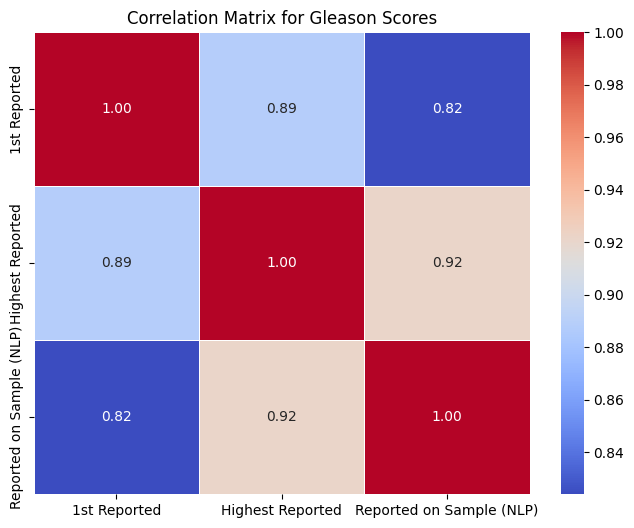

In [14]:
# Subset the relevant columns
gleason_columns = [
    'Gleason Score, 1st Reported',
    'Gleason Score, Highest Reported',
    'Gleason Score Reported on Sample (NLP)'
]

# Compute the correlation matrix
correlation_matrix = df[gleason_columns].corr()

# Rename columns for visualization (remove "Gleason Score")
renamed_columns = {
    'Gleason Score, 1st Reported': '1st Reported',
    'Gleason Score, Highest Reported': 'Highest Reported',
    'Gleason Score Reported on Sample (NLP)': 'Reported on Sample (NLP)'
}

# Update the matrix with the renamed columns
correlation_matrix.rename(index=renamed_columns, columns=renamed_columns, inplace=True)

# Visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix for Gleason Scores')
plt.show()

The correlation matrix reveals that the three Gleason Scores (1st Reported, Highest Reported, and Reported on Sample (NLP)) are strongly correlated, with values of 0.888, 0.824, and 0.921, respectively, indicating a high degree of similarity between them. This suggests redundancy in the data, meaning retaining all three scores could lead to multicollinearity in models. To avoid this, it may be advisable to drop two of the scores, focusing on the most reliable or representative score for analysis.

In this case, Highest Reported Gleason Score is likely the most reliable, as it typically reflects the most significant or advanced cancer finding and has the strongest correlation with the other measures.

In [15]:
# Drop 'Gleason Score, 1st Reported' and 'Gleason Score Reported on Sample (NLP)' columns
df = df.drop(columns=['Gleason Score, 1st Reported', 'Gleason Score Reported on Sample (NLP)'])

# Rename 'Gleason Score, Highest Reported' to 'Gleason Score'
df = df.rename(columns={'Gleason Score, Highest Reported': 'Gleason Score'})

So far, we have only removed redundant Gleanson columns, but we still have 9.64% of missing Gleanson score data that we should address.

To handle this missing data, We are not using using Mean/ Median imputer because in the case of Gleason scores, their values represent distinct categories (e.g., 7, 8, 9, 10), imputing with the mean or median may not make sense because these scores are discrete and represent clinical stages of cancer.

Mode Imputation is likely the best choice in this case, as the Gleason score is a discrete, categorical variable. Using the mode (i.e., the most frequent value) makes clinical sense, especially when dealing with discrete values like 7.0, 8.0, 9.0, and 10.0.

In [16]:
# Replace missing values in the 'Gleason Score' column with its mode

# Calculate the mode
mode_value = df['Gleason Score'].mode()[0]

# Replace missing values with the mode
df['Gleason Score'] = df['Gleason Score'].fillna(mode_value)

Next feature MSI Comment also have relatively high missing percentages (19.73%).

Since the information it provides is already captured by MSI Score and MSI Type, it is considered a redundant feature that adds no unique value to the prediction. Therefore, dropping MSI Comment is a justified decision.

In [17]:
# Drop 'MSI Comment' column
df = df.drop(columns=['MSI Comment'])

# Replace the value "Do not report" with "Unknown" in the MSI Type column
df['MSI Type'] = df['MSI Type'].replace("Do not report", "Unknown")

For Mutation Count, which has 6.02% missing values, the missing data should be handled thoughtfully because the percentage is relatively low, and Mutation Count is an important feature in biological analyses.

In this case we plan to use regression imputation. To handle this missing data, we build a regression model to predict the missing Mutation Count values using related features, such as MSI Score and Tumor Purity.

In [18]:
df_copy = df.copy()

# Step 1: Calculate the mean for MSI Score and Tumor Purity
mean_msi_score = df_copy['MSI Score'].mean()
mean_tumor_purity = df_copy['Tumor Purity'].mean()

# Step 2: Impute the missing MSI Score and Tumor Purity with their respective means
df_copy['MSI Score'] = df_copy['MSI Score'].fillna(mean_msi_score)
df_copy['Tumor Purity'] = df_copy['Tumor Purity'].fillna(mean_tumor_purity)

# Step 3: Prepare the data to train the regression model for Mutation Count
# Separate the rows with missing Mutation Count
train_data = df_copy[df_copy['Mutation Count'].notna()]
test_data = df_copy[df_copy['Mutation Count'].isna()]

# Features and target variable
X_train = train_data[['MSI Score', 'Tumor Purity']]  # Features
y_train = train_data['Mutation Count']              # Target

X_test = test_data[['MSI Score', 'Tumor Purity']]   # Features for missing rows

# Step 4: Train a linear regression model on the available data
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Step 5: Predict missing Mutation Count values
predicted_values = regressor.predict(X_test)

# Step 6: Round the predicted values to nearest integer
predicted_values_int = predicted_values.round().astype(int)

# Step 7: Impute the missing Mutation Count values with the predicted integers
df.loc[df['Mutation Count'].isna(), 'Mutation Count'] = predicted_values_int


Most other columns have less than 1% missing data (e.g., Current Age, Ethnicity, Tumor Purity), which is not likely to affect the overall analysis significantly. We will impute these missing values after dropping redunant columns in the next step because it simplifies the dataset and reduces the computational burden of imputing unnecessary columns.

####Dropping Redundant columns

We can drop columns such as 'Study ID', 'Cancer Type' and 'Number of Samples Per Patient' as they contain identical values and do not contribute to the analysis.

It is a good idea to drop one of the two columns 'Impact TMB Percentile (Across All Tumor Types)' and 'Impact TMB Percentile (Within Tumor Type)' because they have a high correlation of 0.96. A correlation above 0.9 typically indicates that the two features are very similar.

Among Overall Survival (Months) and Overall Survival Statue, we drop survival time beacuse

* Overall Survival (Months) provides a continuous measure of survival duration, but it can introduce bias if the study period is too short to capture full survival, leading to right-censoring. This occurs when patients are still alive or lost to follow-up at the end of the study, making their true survival time unknown.

* On the other hand, Overall Survival Status is a categorical variable indicating whether the patient is alive or deceased by the end of the study. It is less prone to bias but doesn’t provide precise survival time.

* Since the objective of this study is to analyze survival prediction, we prefer to have a categorical value as the output.








In [19]:
# Print the frequency of each unique value in the column
print(df['Number of Samples Per Patient'].value_counts())

Number of Samples Per Patient
1    2254
2       6
Name: count, dtype: int64


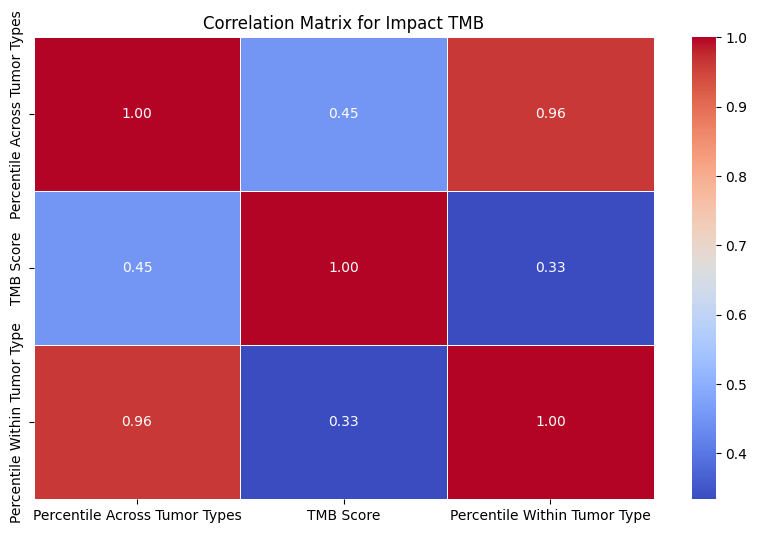

In [20]:
# Calculate the correlation matrix for the selected columns
TMB_correlation_matrix = df[['Impact TMB Percentile (Across All Tumor Types)',
                         'Impact TMB Score',
                         'Impact TMB Percentile (Within Tumor Type)']].corr()

# Rename columns for visualization (remove "Impact TMB")
renamed_columns = {
        'Impact TMB Percentile (Across All Tumor Types)': 'Percentile Across Tumor Types',
        'Impact TMB Score': 'TMB Score',
        'Impact TMB Percentile (Within Tumor Type)': 'Percentile Within Tumor Type',
}

# Update the matrix with the renamed columns
TMB_correlation_matrix.rename(index=renamed_columns, columns=renamed_columns, inplace=True)

# Visualize the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(TMB_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix for Impact TMB')
plt.show()

In [21]:
# Drop the 'Study ID', 'Sample ID' and 'Cancer Type' columns
df = df.drop(columns=['Study ID', 'Sample ID' ,'Cancer Type'])

# Drop the 'Overall Survival (Months)' column
df = df.drop(columns=['Overall Survival (Months)'])

# Drop the 'Number of Samples Per Patient' column
df = df.drop(columns=['Number of Samples Per Patient'])

# Drop the 'TMB Percentile (Within Tumor Type)' column
df = df.drop(columns=['Impact TMB Percentile (Within Tumor Type)'])


####Renaming and cleaning columns for clarity

In [22]:
# Rename 'Overall Survival Status' to 'Survival Status'
df = df.rename(columns={'Overall Survival Status': 'Survival Status'})

# Rename 'Stage (Highest Recorded)' to 'Highest Stage'
df = df.rename(columns={'Stage (Highest Recorded)': 'Highest Stage'})

# Rename 'Impact TMB Percentile (Across All Tumor Types)' to 'Impact TMB Percentile'
df = df.rename(columns={'Impact TMB Percentile (Across All Tumor Types)': 'Impact TMB Percentile'})

# Clean 'Survival Status' column
df['Survival Status'] = df['Survival Status'].str.split(':').str[1]

# Replace any variations like 'LIVING' and 'DECEASED' to proper format
df['Survival Status'] = df['Survival Status'].replace({
    'LIVING': 'Living',
    'DECEASED': 'Deceased'
})

# Reodering 'Survival Status"
column_to_move = 'Survival Status'

# Get the list of columns
columns = df.columns.to_list()

# Remove the column and append it to the end
columns.remove(column_to_move)
columns.append(column_to_move)

# Reorder the DataFrame
df = df[columns]

To clean the Ethnicity data, we can group similar or redundant categories using a mapping technique. This involves  overlapping values, such as various "Unknown" or Hispanic-related categories, into broader groups like "Non-Hispanic," "Hispanic," and "Unknown." Additionally, standardizing the naming ensures a consistent format across the dataset, simplifying the data for further analysis.

In [23]:
print(df['Ethnicity'].value_counts())

Ethnicity
Non-Spanish; Non-Hispanic                             2017
Unknown whether Spanish or not                         129
Spanish  NOS; Hispanic NOS, Latino NOS                  79
South/Central America (except Brazil)                   10
Unknown                                                 10
Puerto Rican                                             8
Dominican Republic                                       3
Mexican (includes Chicano)                               1
Other Spanish/Hispanic(incl European; excl Dom Rep       1
Cuban                                                    1
Name: count, dtype: int64


In [24]:
# Create a mapping for Ethnicity cleaning
ethnicity_mapping = {
    'Non-Spanish; Non-Hispanic': 'Non-Hispanic',
    'Unknown whether Spanish or not': 'Unknown',
    'Spanish  NOS; Hispanic NOS, Latino NOS': 'Hispanic',
    'South/Central America (except Brazil)': 'Hispanic',
    'Unknown': 'Unknown',
    'Puerto Rican': 'Hispanic',
    'Dominican Republic': 'Hispanic',
    'Mexican (includes Chicano)': 'Hispanic',
    'Other Spanish/Hispanic(incl European; excl Dom Rep': 'Hispanic',
    'Cuban': 'Hispanic'
}

# Apply the mapping to the DataFrame
df['Ethnicity'] = df['Ethnicity'].map(ethnicity_mapping)

# Display the cleaned Ethnicity column
print(df['Ethnicity'].value_counts())

Ethnicity
Non-Hispanic    2017
Unknown          139
Hispanic         103
Name: count, dtype: int64


In [25]:
# Create a mapping to standardize and merge categories
race_mapping = {
    'Black Or African American': 'Black',
    'Asian-Far East/Indian Subcont': 'Asian',
    'Patient Refused To Answer': 'Unknown',
    'No Value Entered': 'Unknown',
    'Unknown': 'Unknown',
    'Native Hawaiian Or Pacific Isl': 'Other'
}

# Apply the mapping to the DataFrame
df['Race'] = df['Race'].map(race_mapping).fillna(df['Race'])

# Display the cleaned Race column
print(df['Race'].value_counts())

Race
White      1865
Black       175
Unknown      96
Asian        81
Other        42
Name: count, dtype: int64


In [26]:
df.head(5)

,Patient ID,Cancer Type Detailed,Current Age,Impact TMB Percentile,Impact TMB Score,Ethnicity,Fraction Genome Altered,Gene Panel,Gleason Score,MSI Score,MSI Type,Mutation Count,Oncotree Code,Race,Sample coverage,Sample Type,Somatic Status,Highest Stage,Tumor Purity,Survival Status
0,P-0000140,Prostate Neuroendocrine Carcinoma,45.0,17.3,1.1,Non-Hispanic,0.5462,IMPACT341,9.0,0.67,Stable,1.0,PRNE,White,629,Metastasis,Matched,Stage 4,60.0,Deceased
1,P-0000197,Prostate Adenocarcinoma,80.0,44.1,3.3,Non-Hispanic,0.0604,IMPACT341,9.0,0.09,Stable,3.0,PRAD,White,1188,Metastasis,Matched,Stage 4,30.0,Deceased
2,P-0000318,Prostate Adenocarcinoma,67.0,44.1,3.3,Non-Hispanic,0.5589,IMPACT341,10.0,1.67,Stable,3.0,PRAD,Unknown,782,Metastasis,Matched,Stage 4,60.0,Deceased
3,P-0000373,Prostate Adenocarcinoma,58.0,17.3,1.1,Non-Hispanic,0.0023,IMPACT341,9.0,0.09,Stable,1.0,PRAD,White,708,Metastasis,Matched,Stage 4,60.0,Deceased
4,P-0000377,Prostate Adenocarcinoma,64.0,86.6,10.0,Non-Hispanic,0.4249,IMPACT341,9.0,2.73,Stable,9.0,PRAD,White,805,Primary,Matched,Stage 4,80.0,Deceased


####Outlier detection

Outliers in Mutation Count:
      Mutation Count
203             73.0
637             61.0
691            108.0
840             52.0
845             77.0
907             75.0
909             65.0
962             58.0
1023            76.0
1073            79.0
1096            88.0
1151            61.0
1166            85.0
1180            87.0
1232            64.0
1244            64.0
1270            69.0
1282           539.0
1291           208.0
1355            67.0
1368            56.0
1501           191.0
1810            78.0
2132            92.0
2161            85.0
2200            61.0


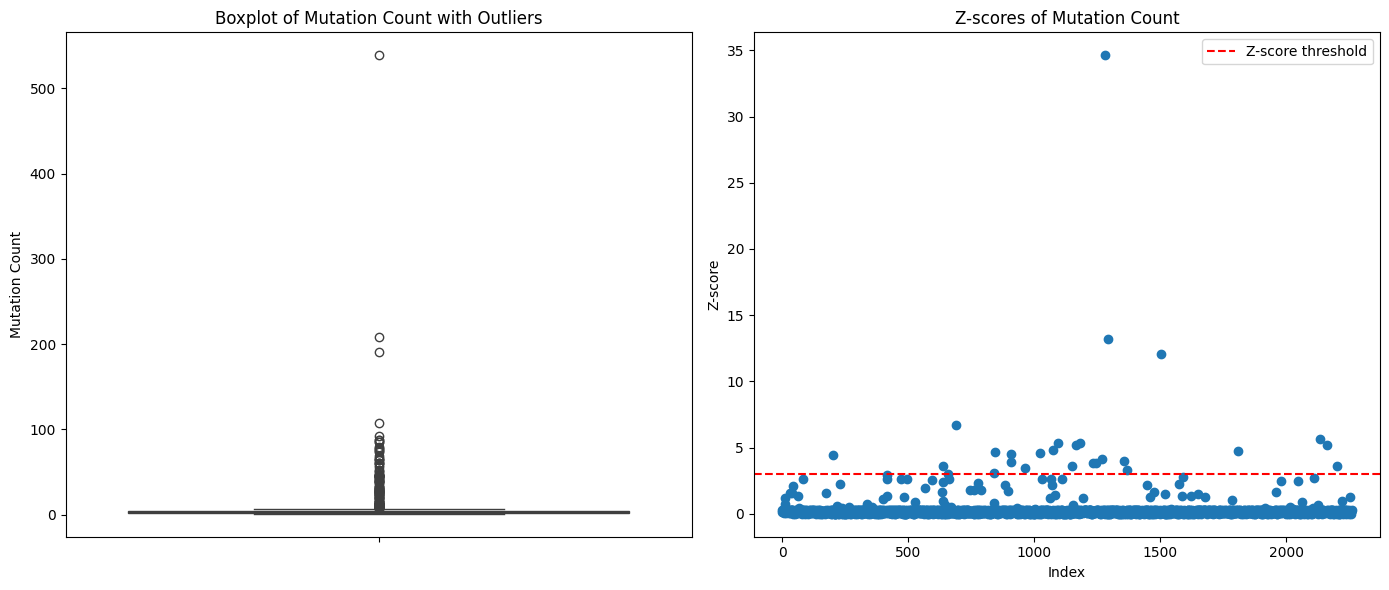

Outliers in Sample coverage:
      Sample coverage
26               1267
85               1293
93               1473
249              2148
291              1409
333              1341
400              1331
458              1449
465              1286
497              1336
518              1267
520              1544
521              1492
524              1269
808              1544
1086             1526


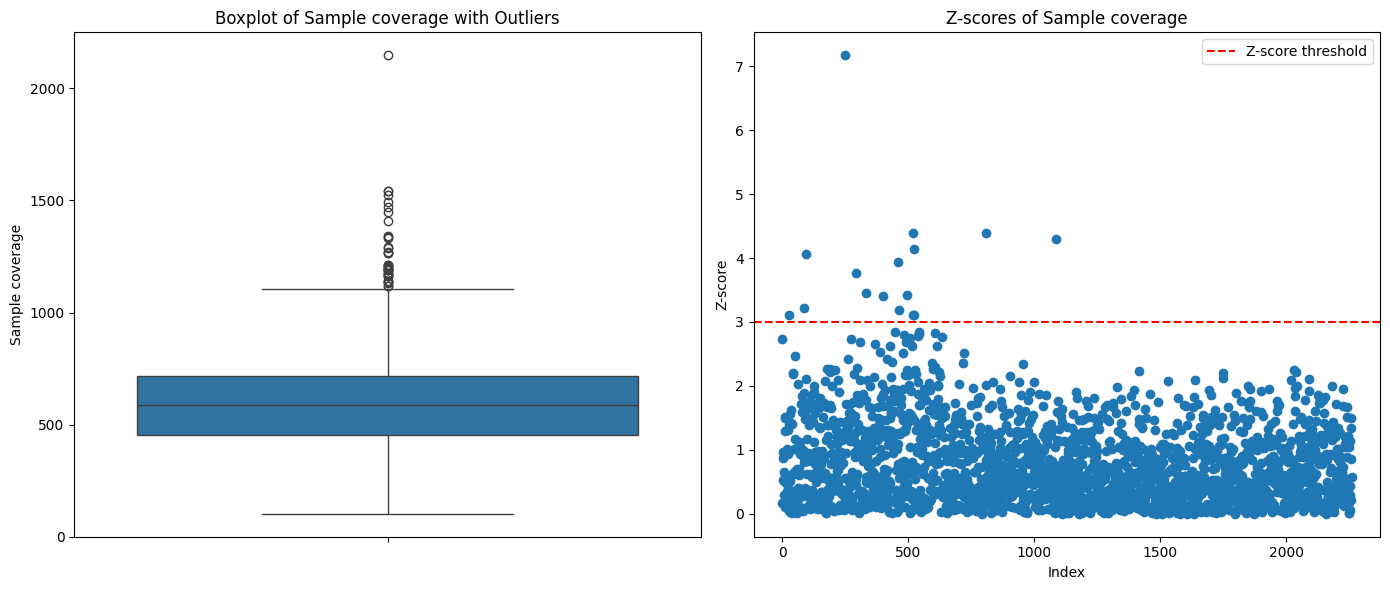

In [27]:
# Function to detect outliers using Z-scores
def detect_outliers(df, column, threshold=3):
    z_scores = np.abs(stats.zscore(df[column]))
    return df[z_scores > threshold], z_scores

# Function to visualize outliers for each numerical column in the dataframe
def visualize_outliers(df):
    numerical_columns = df.select_dtypes(include=[np.number]).columns
    for column in numerical_columns:
        outliers, z_scores = detect_outliers(df, column)
        if not outliers.empty:
            print(f"Outliers in {column}:")
            print(outliers[[column]])
            plt.figure(figsize=(14, 6))
            plt.subplot(1, 2, 1)
            sns.boxplot(df[column])
            plt.title(f"Boxplot of {column} with Outliers")
            plt.subplot(1, 2, 2)
            plt.scatter(df.index, z_scores)
            plt.axhline(y=3, color='r', linestyle='--', label='Z-score threshold')
            plt.title(f"Z-scores of {column}")
            plt.xlabel('Index')
            plt.ylabel('Z-score')
            plt.legend()

            plt.tight_layout()
            plt.show()

visualize_outliers(df)

1. Mutation Count: Multiple outliers with values around 200 and one significant outlier with value much higher than most observations (up to 539). For prostate cancer, mutation counts typically range from tens to a around two hundred mutations. Values higher than this, such as 539 mutations, may be considered outliers.

2. Sample Coverage: Sample coverage refers to the proportion of the genome that is analyzed or sequenced in a biological sample. In the context of cancer studies, it typically indicates the depth of sequencing or the extent of genomic information available from the sample. Since it is possible to have this range of sample coverage, these values are not outliers.


In [28]:
# Remove a single observation if it's an outlier
df = df[df['Mutation Count'] != 539]

In [29]:
df.describe()

,Current Age,Impact TMB Percentile,Impact TMB Score,Fraction Genome Altered,Gleason Score,MSI Score,Mutation Count,Sample coverage,Tumor Purity
count,2258.000000,2209.000000,2209.000000,2252.000000,2259.000000,2250.000000,2259.000000,2259.000000,2243.000000
mean,70.914083,36.465595,4.206021,0.156916,8.223993,1.024929,4.749447,593.789287,40.007133
std,8.911999,22.244442,9.475071,0.155435,0.908249,3.673912,10.566886,216.771279,19.601470
min,40.000000,-1.000000,-1.000000,0.000000,6.000000,-1.000000,1.000000,102.000000,10.000000
25%,65.000000,18.000000,1.600000,0.031925,7.000000,0.000000,2.000000,455.000000,25.000000
50%,71.000000,37.900000,2.600000,0.114050,9.000000,0.180000,3.000000,589.000000,40.000000
75%,77.000000,49.500000,3.900000,0.231275,9.000000,0.660000,4.000000,716.500000,50.000000
max,89.000000,99.900000,182.600000,0.796500,10.000000,41.110000,208.000000,2148.000000,95.000000


####Imputing missing values for rest of the data


In [30]:
print(df.dtypes)

Patient ID                  object
Cancer Type Detailed        object
Current Age                float64
Impact TMB Percentile      float64
Impact TMB Score           float64
Ethnicity                   object
Fraction Genome Altered    float64
Gene Panel                  object
Gleason Score              float64
MSI Score                  float64
MSI Type                    object
Mutation Count             float64
Oncotree Code               object
Race                        object
Sample coverage              int64
Sample Type                 object
Somatic Status              object
Highest Stage               object
Tumor Purity               float64
Survival Status             object
dtype: object


In [31]:
# Handle missing values for the rest
for column in df.columns:
    if df[column].dtype == 'object':
        # Handling missing categorical values (imputing with 'Unknown')
        df.loc[:, column] = df[column].fillna('Unknown')
    else:
        # Handling missing numerical values (imputing with median)
        df.loc[:, column] = df[column].fillna(df[column].median())


##EXPLORATORY ANALYSIS & DATA VISUALIZATION

In this part of the data analysis process, we’ll take a closer look at the data through graphs and visualizations to better understand its patterns. We’ll also use statistical methods to back up the trends we spot with some solid evidence.

In this section it is all about exploring the data in more detail and uncovering meaningful insights.

Lets explore the characteristics of the Data

In [32]:
print("Shape of the data:", df.shape)

Shape of the data: (2259, 20)


In [33]:
df.head()

,Patient ID,Cancer Type Detailed,Current Age,Impact TMB Percentile,Impact TMB Score,Ethnicity,Fraction Genome Altered,Gene Panel,Gleason Score,MSI Score,MSI Type,Mutation Count,Oncotree Code,Race,Sample coverage,Sample Type,Somatic Status,Highest Stage,Tumor Purity,Survival Status
0,P-0000140,Prostate Neuroendocrine Carcinoma,45.0,17.3,1.1,Non-Hispanic,0.5462,IMPACT341,9.0,0.67,Stable,1.0,PRNE,White,629,Metastasis,Matched,Stage 4,60.0,Deceased
1,P-0000197,Prostate Adenocarcinoma,80.0,44.1,3.3,Non-Hispanic,0.0604,IMPACT341,9.0,0.09,Stable,3.0,PRAD,White,1188,Metastasis,Matched,Stage 4,30.0,Deceased
2,P-0000318,Prostate Adenocarcinoma,67.0,44.1,3.3,Non-Hispanic,0.5589,IMPACT341,10.0,1.67,Stable,3.0,PRAD,Unknown,782,Metastasis,Matched,Stage 4,60.0,Deceased
3,P-0000373,Prostate Adenocarcinoma,58.0,17.3,1.1,Non-Hispanic,0.0023,IMPACT341,9.0,0.09,Stable,1.0,PRAD,White,708,Metastasis,Matched,Stage 4,60.0,Deceased
4,P-0000377,Prostate Adenocarcinoma,64.0,86.6,10.0,Non-Hispanic,0.4249,IMPACT341,9.0,2.73,Stable,9.0,PRAD,White,805,Primary,Matched,Stage 4,80.0,Deceased


In [34]:
# Check if there are any duplicate rows

duplicates = df.duplicated()
print("Any duplicates?", duplicates.any())
print("Number of duplicate rows:", duplicates.sum())

Any duplicates? False
Number of duplicate rows: 0


In [35]:
# Display the features availble in the dataset after cleaning

print("Features in the dataset:", df.columns.tolist())

Features in the dataset: ['Patient ID', 'Cancer Type Detailed', 'Current Age', 'Impact TMB Percentile', 'Impact TMB Score', 'Ethnicity', 'Fraction Genome Altered', 'Gene Panel', 'Gleason Score', 'MSI Score', 'MSI Type', 'Mutation Count', 'Oncotree Code', 'Race', 'Sample coverage', 'Sample Type', 'Somatic Status', 'Highest Stage', 'Tumor Purity', 'Survival Status']


These are the key features of the dataset after cleaning

* Clinical Demographics:
Current Age, Ethnicity, Race

* Clinical Features:
Gleason Score, Highest Stage, Tumor Purity, Sample Type, MSI Score, MSI Type

* Genomic Features:
Impact TMB Percentile, Impact TMB Score, Fraction Genome Altered, Gene Panel and Mutation Count

* Outcome:
Survival Status (Target variable for survival analysis: "Alive" or "Deceased")

####Transformations

Transforming your data before analysis can improve the clarity and relevance of your insights.

Plan for Transformation

1. Renaming values in Patient ID with ID and typecasting it to int

2. One hot encoding of MSI Type, Sample Type, Highest Stage, Ethinicity, Race, Cancer Type, Gene Panel, Oncotree code,

3. Renaming few column names for better clarity and droping redundant columns likeLiving Sample_Unknown and Sample_Local Recurrence because they have only 1 or 2 values

4. Since Survival Status is categorical, create a binary survival target (0 = Deceased, 1 = Living)

In [36]:
print(df['Highest Stage'].value_counts())

Highest Stage
Stage 4      1025
Stage 1-3     944
Unknown       290
Name: count, dtype: int64


In [37]:
# Create a copy of the DataFrame for tranformed
df_transformed = df.copy()

# One-hot encoding of 'MSI Type'
df_transformed = pd.get_dummies(df_transformed, columns=['MSI Type'], prefix='MSI')

# One-hot encoding of 'Sample Type'
df_transformed = pd.get_dummies(df_transformed, columns=['Sample Type'], prefix='Sample')

# One-hot encoding of 'Highest Stage'
df_transformed = pd.get_dummies(df_transformed, columns=['Highest Stage'], prefix='Stage')

# One-hot encoding of 'Ethnicity'
df_transformed = pd.get_dummies(df_transformed, columns=['Ethnicity'], prefix='Ethnicity')

# One-hot encoding of 'Race'
df_transformed = pd.get_dummies(df_transformed, columns=['Race'], prefix='Race')

# One-hot encoding of 'Cancer Type Detailed'
df_transformed = pd.get_dummies(df_transformed, columns=['Cancer Type Detailed'], prefix='')

# One-hot encoding of 'Gene Panel'
df_transformed = pd.get_dummies(df_transformed, columns=['Gene Panel'], prefix='Gene')

# One-hot encoding of 'Oncotree Code'
df_transformed = pd.get_dummies(df_transformed, columns=['Oncotree Code'], prefix='Oncotree_Code')\

# Renaming 'Patient ID' with ID and typecasting it to int
df_transformed['Patient ID'] = df_transformed['Patient ID'].str.replace('P-', '').astype(int)

# Rename the column 'Stage_Stage 1-3' to your desired name
df_transformed = df_transformed.rename(columns={'Stage_Stage 1-3': 'Stage 1-3'})

# Rename the column 'Stage_Stage 1-3' to your desired name
df_transformed = df_transformed.rename(columns={'Stage_Stage 4': 'Stage 4'})

# Dropping the 'Sample_Local Recurrence' column from the DataFrame
df_transformed = df_transformed.drop(columns=['Sample_Local Recurrence'])

# Dropping the 'Sample_Unknown' column from the DataFrame
df_transformed = df_transformed.drop(columns=['Sample_Unknown'])

# Transform the Survival Status column
df_transformed['Survival Status'] = df_transformed['Survival Status'].map({'Deceased': 0, 'Living': 1})

# Transform the Somatic Status column
df_transformed['Somatic Status'] = df_transformed['Somatic Status'].map({'Matched': 1, 'Unmatched': 0})

In [38]:
df_transformed.head()

,Patient ID,Current Age,Impact TMB Percentile,Impact TMB Score,Fraction Genome Altered,Gleason Score,MSI Score,Mutation Count,Sample coverage,Somatic Status,...,_Prostate Small Cell Carcinoma,_Prostate Squamous Cell Carcinoma,Gene_IMPACT341,Gene_IMPACT410,Gene_IMPACT468,Gene_IMPACT505,Oncotree_Code_PRAD,Oncotree_Code_PRNE,Oncotree_Code_PRSC,Oncotree_Code_PRSCC
0,140,45.0,17.3,1.1,0.5462,9.0,0.67,1.0,629,1,...,False,False,True,False,False,False,False,True,False,False
1,197,80.0,44.1,3.3,0.0604,9.0,0.09,3.0,1188,1,...,False,False,True,False,False,False,True,False,False,False
2,318,67.0,44.1,3.3,0.5589,10.0,1.67,3.0,782,1,...,False,False,True,False,False,False,True,False,False,False
3,373,58.0,17.3,1.1,0.0023,9.0,0.09,1.0,708,1,...,False,False,True,False,False,False,True,False,False,False
4,377,64.0,86.6,10.0,0.4249,9.0,2.73,9.0,805,1,...,False,False,True,False,False,False,True,False,False,False


In [39]:
# Print the list of columns present in the original DataFrame (df)
print("Original columns:", df.columns.tolist())

# Print the list of new columns added to the transformed DataFrame (df_transformed)
print("\nNew columns added:", [col for col in df_transformed.columns if col not in df.columns])

Original columns: ['Patient ID', 'Cancer Type Detailed', 'Current Age', 'Impact TMB Percentile', 'Impact TMB Score', 'Ethnicity', 'Fraction Genome Altered', 'Gene Panel', 'Gleason Score', 'MSI Score', 'MSI Type', 'Mutation Count', 'Oncotree Code', 'Race', 'Sample coverage', 'Sample Type', 'Somatic Status', 'Highest Stage', 'Tumor Purity', 'Survival Status']

New columns added: ['MSI_Indeterminate', 'MSI_Instable', 'MSI_Stable', 'MSI_Unknown', 'Sample_Metastasis', 'Sample_Primary', 'Stage 1-3', 'Stage 4', 'Stage_Unknown', 'Ethnicity_Hispanic', 'Ethnicity_Non-Hispanic', 'Ethnicity_Unknown', 'Race_Asian', 'Race_Black', 'Race_Other', 'Race_Unknown', 'Race_White', '_Prostate Adenocarcinoma', '_Prostate Neuroendocrine Carcinoma', '_Prostate Small Cell Carcinoma', '_Prostate Squamous Cell Carcinoma', 'Gene_IMPACT341', 'Gene_IMPACT410', 'Gene_IMPACT468', 'Gene_IMPACT505', 'Oncotree_Code_PRAD', 'Oncotree_Code_PRNE', 'Oncotree_Code_PRSC', 'Oncotree_Code_PRSCC']


In [40]:
summary_df = pd.DataFrame({
    'Column': df_transformed.columns,
    'Unique Elements': [df_transformed[col].nunique() for col in df_transformed.columns],
    'Top 5 Elements': [list(df_transformed[col].unique())[:5] for col in df_transformed.columns],
    "type":[df_transformed[col].dtype for col in df_transformed.columns]
})

summary_df

,Column,Unique Elements,Top 5 Elements,type
0,Patient ID,2256,"[140, 197, 318, 373, 377]",int64
1,Current Age,47,"[45.0, 80.0, 67.0, 58.0, 64.0]",float64
2,Impact TMB Percentile,115,"[17.3, 44.1, 86.6, 37.9, 74.4]",float64
3,Impact TMB Score,114,"[1.1, 3.3, 10.0, 2.6, 6.7]",float64
4,Fraction Genome Altered,1605,"[0.5462, 0.0604, 0.5589, 0.0023, 0.4249]",float64
5,Gleason Score,5,"[9.0, 10.0, 8.0, 7.0, 6.0]",float64
6,MSI Score,330,"[0.67, 0.09, 1.67, 2.73, 0.0]",float64
7,Mutation Count,67,"[1.0, 3.0, 9.0, 2.0, 6.0]",float64
8,Sample coverage,804,"[629, 1188, 782, 708, 805]",int64
9,Somatic Status,2,"[1, 0]",int64


Exploring the dataset by analyzing data types, missing values, and visualizing the distribution of numeric variables in the DataFrame


The dataset has been thoroughly cleaned and preprocessed, with all categorical variables successfully encoded into numerical or boolean formats. Additionally, there are no missing or null values remaining in the dataset, ensuring its completeness. All numerical columns have been carefully examined, and distribution plots have been generated for each one.

Below visualizations revels that the data is well-structured and exhibits clear, consistent patterns, which will support good analysis and modeling.


Exploring Variable: Patient ID
Data Type: int64
Unique Values: 2256
Missing Percentage: 0.0%
count     2259.000000
mean     30597.287295
std      18674.187803
min        140.000000
25%      12143.000000
50%      30717.000000
75%      47130.500000
max      62933.000000
Name: Patient ID, dtype: float64


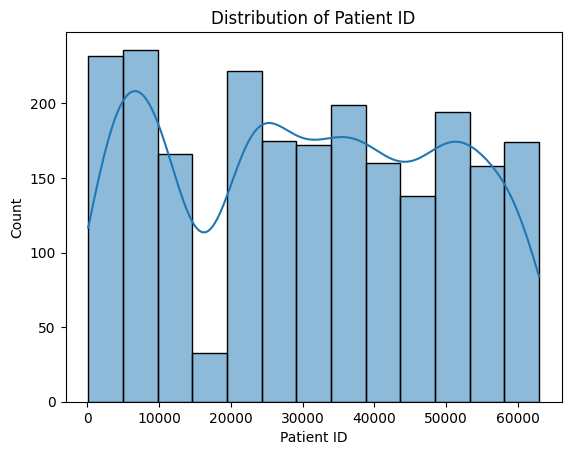


Exploring Variable: Current Age
Data Type: float64
Unique Values: 47
Missing Percentage: 0.0%
count    2259.000000
mean       70.914121
std         8.910025
min        40.000000
25%        65.000000
50%        71.000000
75%        77.000000
max        89.000000
Name: Current Age, dtype: float64


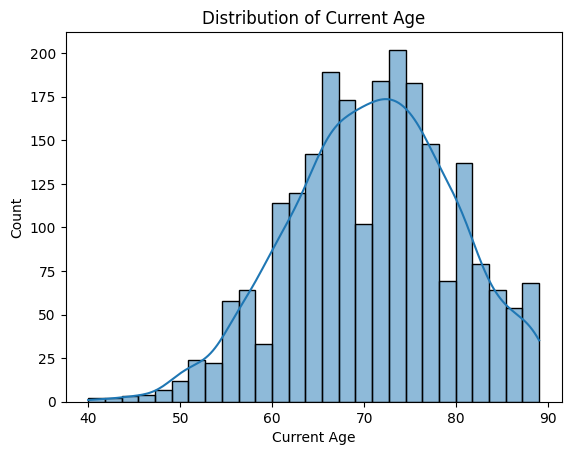


Exploring Variable: Impact TMB Percentile
Data Type: float64
Unique Values: 115
Missing Percentage: 0.0%
count    2259.000000
mean       36.497344
std        21.997792
min        -1.000000
25%        18.000000
50%        37.900000
75%        44.100000
max        99.900000
Name: Impact TMB Percentile, dtype: float64


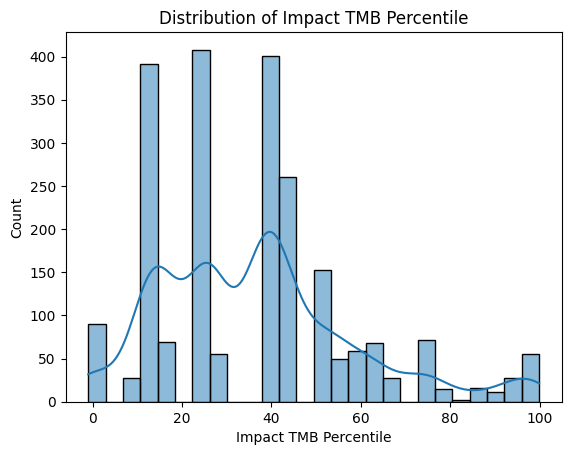


Exploring Variable: Impact TMB Score
Data Type: float64
Unique Values: 114
Missing Percentage: 0.0%
count    2259.000000
mean        4.170474
std         9.372558
min        -1.000000
25%         1.600000
50%         2.600000
75%         3.500000
max       182.600000
Name: Impact TMB Score, dtype: float64


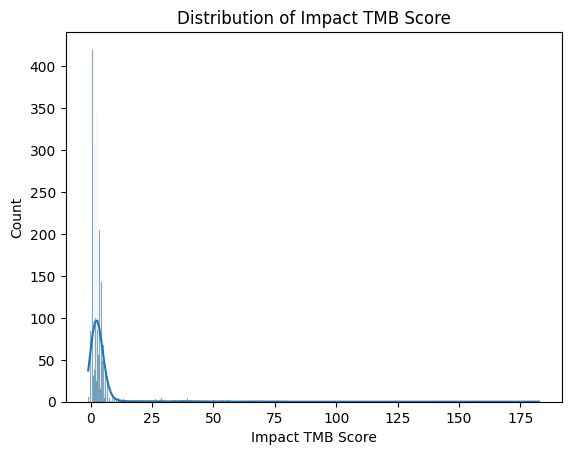


Exploring Variable: Fraction Genome Altered
Data Type: float64
Unique Values: 1605
Missing Percentage: 0.0%
count    2259.000000
mean        0.156783
std         0.155212
min         0.000000
25%         0.032050
50%         0.114050
75%         0.230550
max         0.796500
Name: Fraction Genome Altered, dtype: float64


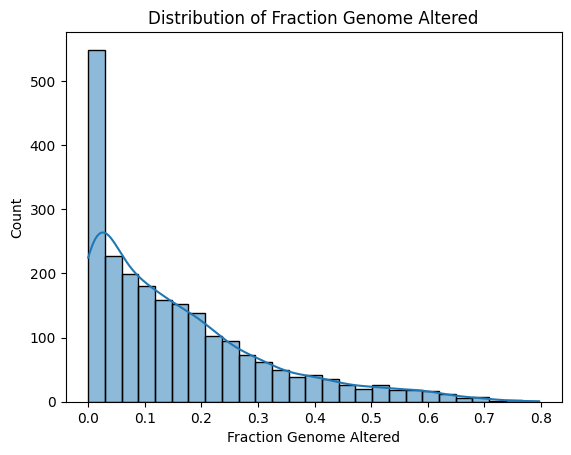


Exploring Variable: Gleason Score
Data Type: float64
Unique Values: 5
Missing Percentage: 0.0%
count    2259.000000
mean        8.223993
std         0.908249
min         6.000000
25%         7.000000
50%         9.000000
75%         9.000000
max        10.000000
Name: Gleason Score, dtype: float64


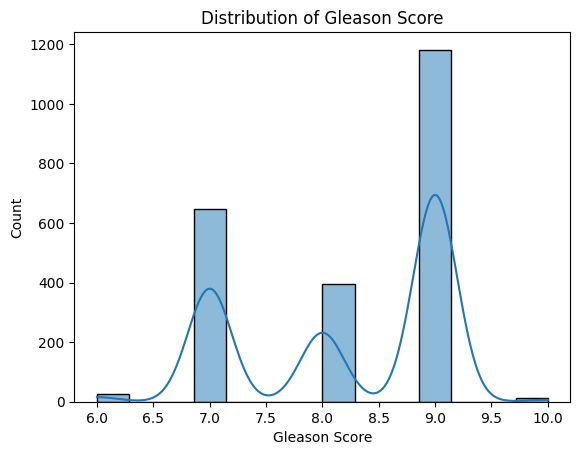


Exploring Variable: MSI Score
Data Type: float64
Unique Values: 330
Missing Percentage: 0.0%
count    2259.000000
mean        1.021563
std         3.666970
min        -1.000000
25%         0.000000
50%         0.180000
75%         0.655000
max        41.110000
Name: MSI Score, dtype: float64


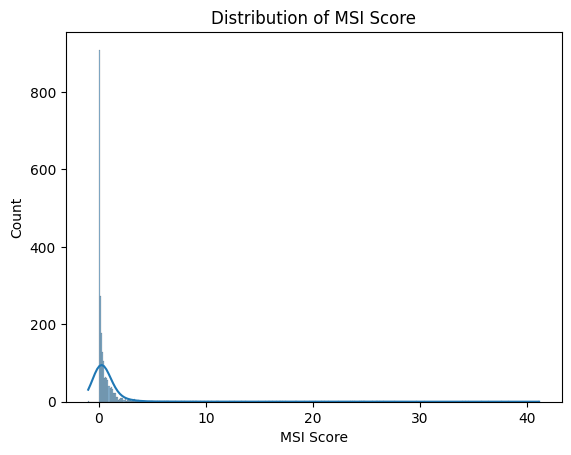


Exploring Variable: Mutation Count
Data Type: float64
Unique Values: 67
Missing Percentage: 0.0%
count    2259.000000
mean        4.749447
std        10.566886
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max       208.000000
Name: Mutation Count, dtype: float64


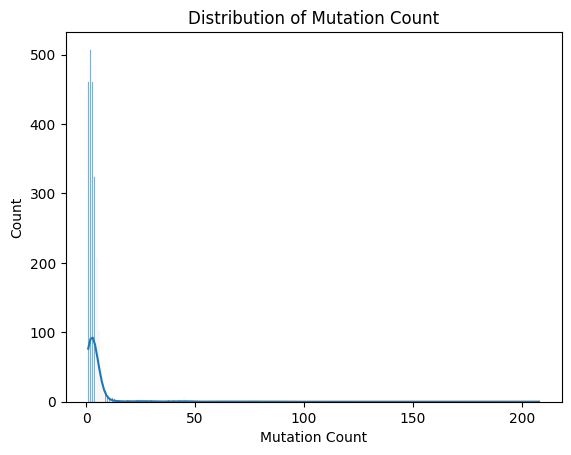


Exploring Variable: Sample coverage
Data Type: int64
Unique Values: 804
Missing Percentage: 0.0%
count    2259.000000
mean      593.789287
std       216.771279
min       102.000000
25%       455.000000
50%       589.000000
75%       716.500000
max      2148.000000
Name: Sample coverage, dtype: float64


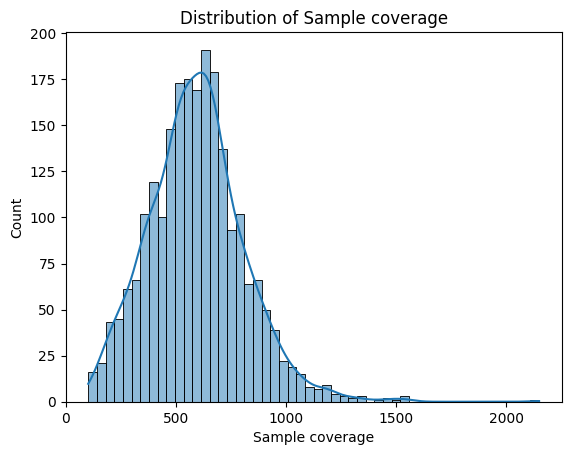


Exploring Variable: Somatic Status
Data Type: int64
Unique Values: 2
Missing Percentage: 0.0%
count    2259.000000
mean        0.997787
std         0.047005
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Somatic Status, dtype: float64


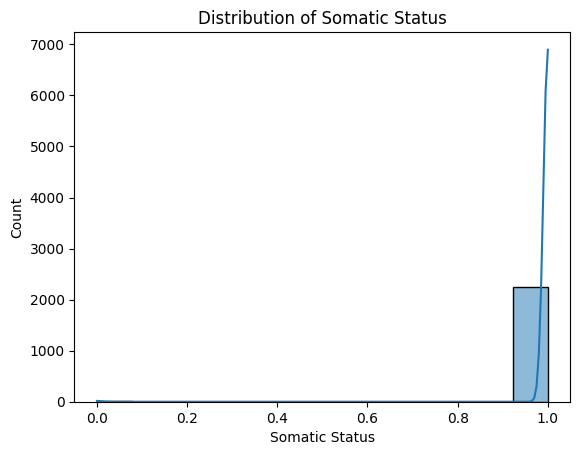


Exploring Variable: Tumor Purity
Data Type: float64
Unique Values: 17
Missing Percentage: 0.0%
count    2259.000000
mean       40.007083
std        19.531899
min        10.000000
25%        27.500000
50%        40.000000
75%        50.000000
max        95.000000
Name: Tumor Purity, dtype: float64


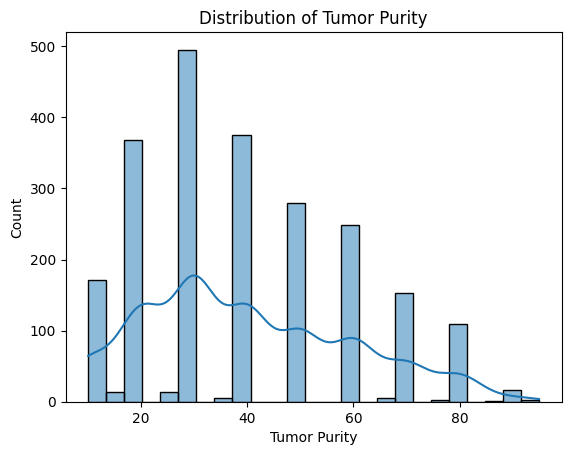


Exploring Variable: Survival Status
Data Type: float64
Unique Values: 2
Missing Percentage: 0.04426737494466578%
Missing values in Survival Status handled.
count    2259.000000
mean        0.593625
std         0.491265
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Survival Status, dtype: float64


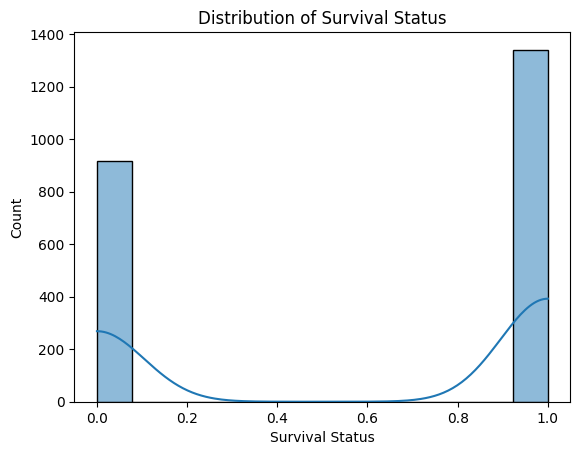


Exploring Variable: MSI_Indeterminate
Data Type: bool
Unique Values: 2
Missing Percentage: 0.0%

Exploring Variable: MSI_Instable
Data Type: bool
Unique Values: 2
Missing Percentage: 0.0%

Exploring Variable: MSI_Stable
Data Type: bool
Unique Values: 2
Missing Percentage: 0.0%

Exploring Variable: MSI_Unknown
Data Type: bool
Unique Values: 2
Missing Percentage: 0.0%

Exploring Variable: Sample_Metastasis
Data Type: bool
Unique Values: 2
Missing Percentage: 0.0%

Exploring Variable: Sample_Primary
Data Type: bool
Unique Values: 2
Missing Percentage: 0.0%

Exploring Variable: Stage 1-3
Data Type: bool
Unique Values: 2
Missing Percentage: 0.0%

Exploring Variable: Stage 4
Data Type: bool
Unique Values: 2
Missing Percentage: 0.0%

Exploring Variable: Stage_Unknown
Data Type: bool
Unique Values: 2
Missing Percentage: 0.0%

Exploring Variable: Ethnicity_Hispanic
Data Type: bool
Unique Values: 2
Missing Percentage: 0.0%

Exploring Variable: Ethnicity_Non-Hispanic
Data Type: bool
Unique Value

In [41]:
for column in df_transformed.columns:
    dtype = df_transformed[column].dtype
    unique_values = df_transformed[column].nunique()
    missing_percentage = df_transformed[column].isnull().mean() * 100
    print(f"\nExploring Variable: {column}")
    print(f"Data Type: {dtype}")
    print(f"Unique Values: {unique_values}")
    print(f"Missing Percentage: {missing_percentage}%")

    if missing_percentage > 0:
        if dtype == 'object':
            df_transformed[column].fillna("Unknown", inplace=True)
        else:
            df_transformed[column].fillna(df_transformed[column].median(), inplace=True)
        print(f"Missing values in {column} handled.")

    if np.issubdtype(dtype, np.number):
        print(df_transformed[column].describe())
        sns.histplot(df_transformed[column], kde=True)
        plt.title(f"Distribution of {column}")
        plt.show()

Lets start with demographic analysis of Survival status by Age.


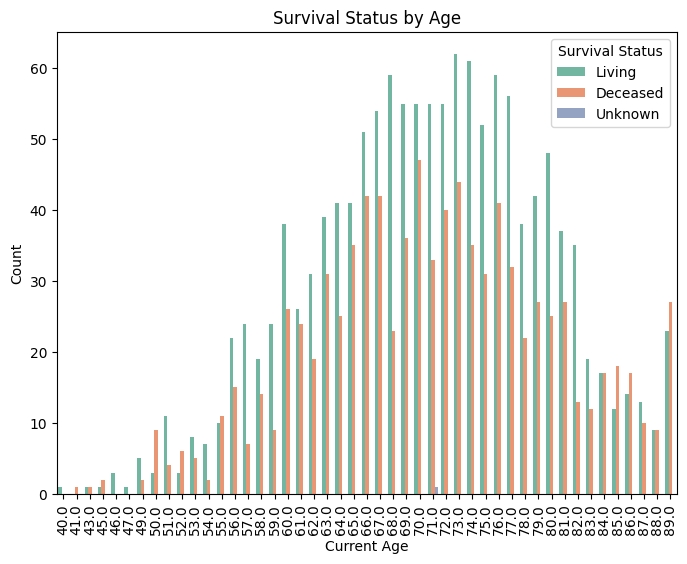

In [42]:
# Survival rate by Ethnicity
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Current Age', hue='Survival Status', palette='Set2')
plt.title('Survival Status by Age')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

The data suggests a clear relationship between age and survival status, where older individuals are more likely to be deceased. Overall, it illustrates the typical trend where mortality increases with age.

Now, lets look at other demographics like Race and Ethnicity

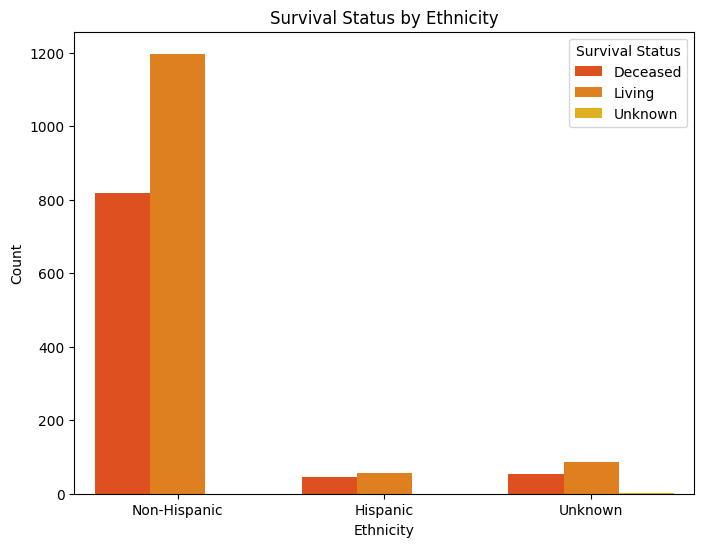

In [43]:
# Survival rate by Ethnicity
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Ethnicity', hue='Survival Status', palette='autumn')
plt.title('Survival Status by Ethnicity')
plt.ylabel('Count')
plt.xticks
plt.show()

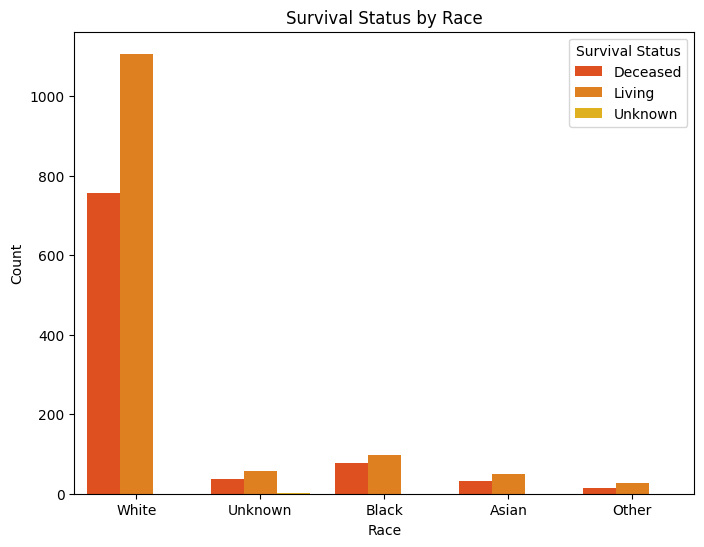

In [44]:
# Survival rate by Race
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Race', hue='Survival Status', palette='autumn')
plt.title('Survival Status by Race')
plt.ylabel('Count')
plt.xticks
plt.show()


These plots shows dominance of "Non-Hispanic" individuals and indicates that the majority of individuals belong to the White race, with a significant number of deceased individuals. The number of individuals is much lower for other racial categories but, the survival status appears to be similarly distributed between living and deceased, although the total count is smaller.

Unfortunately, we also have a good number of Unknown race / ethinicity because there a significant number of people who prefer not to mention it.

Since, we have some missing values here, it is difficult to get the exact piture on the survival rate by race or ethinicity. Nevertheless, we will look at the clinical features next.

These are the Clinical Features we have in our dataset: Gleason Score, Highest Stage, Tumor Purity, Sample Type, MSI Score, MSI Type

Lets begin with Survial Status by Tumor Stage

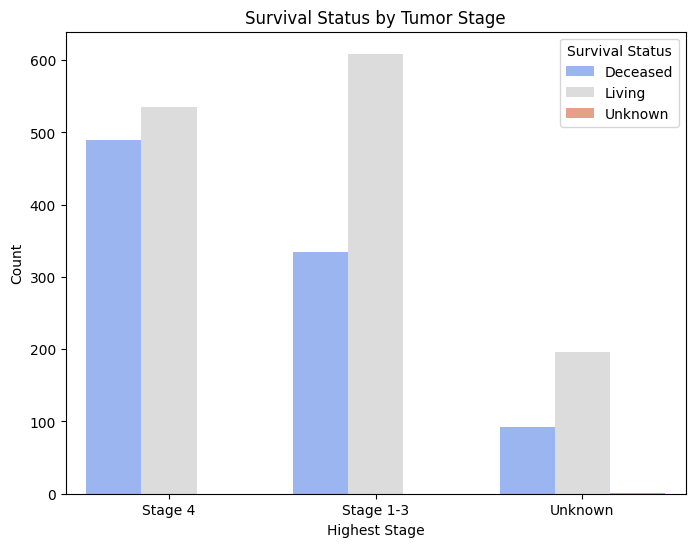

In [45]:
# Stage distribution and Survival
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Highest Stage', hue='Survival Status', palette='coolwarm')
plt.title('Survival Status by Tumor Stage')
plt.ylabel('Count')
plt.xticks
plt.show()

From Tumor Stage graph, we can clearly interpret that patients wtih their heighest recorded Tumor stage between 1 to 3 have a signicanlty high survival rate compared to people with stage 4 tumor.

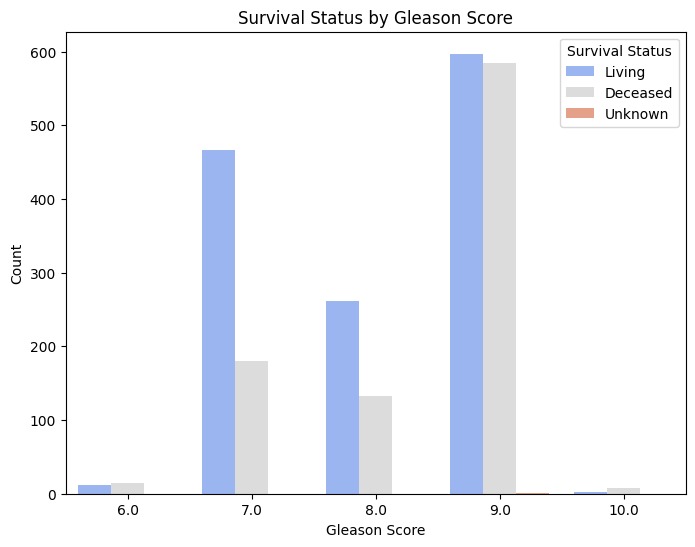

In [46]:
# Gleason Score and Survival
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Gleason Score', hue='Survival Status', palette='coolwarm')
plt.title('Survival Status by Gleason Score')
plt.ylabel('Count')
plt.xticks
plt.show()

Low scores are rare and refelect ealry-stage cases. Trends from this plot suggests that, mid-range Gleason Score of 7-8 indicates better survival rate. Higher Gleason scores of (9) are the most frequent in the population, but the numbers for living and deceased are close enough.


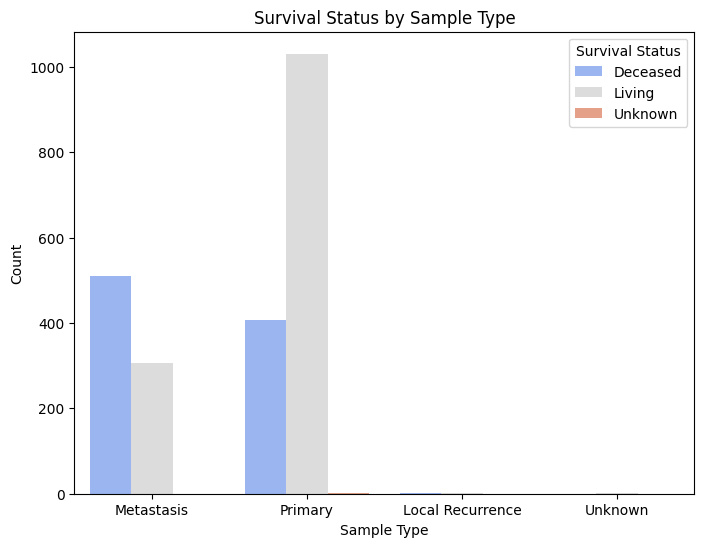

In [47]:
# Sample Type and Survival
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Sample Type', hue='Survival Status', palette='coolwarm')
plt.title('Survival Status by Sample Type')
plt.ylabel('Count')
plt.xticks
plt.show()

Sample type gives an intresting insight about
Metastasis sample type having less survival numbers compared to primary which has significantly high number of surviver.

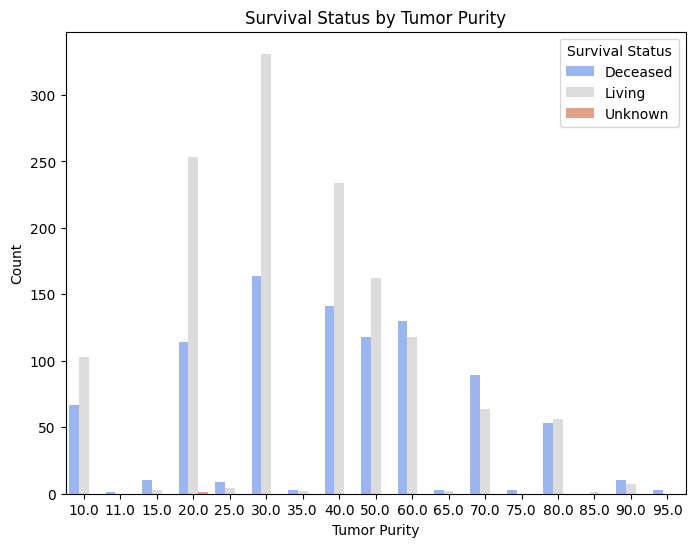

In [48]:
# Tumor Purity and Survival
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Tumor Purity', hue='Survival Status', palette='coolwarm')
plt.title('Survival Status by Tumor Purity')
plt.ylabel('Count')
plt.xticks
plt.show()

Tumor purity is also intresting feature and seems to be very important one in this analysis, as we can see the count of deceased patients overtaking survivors when the tumor purity goes past 60  

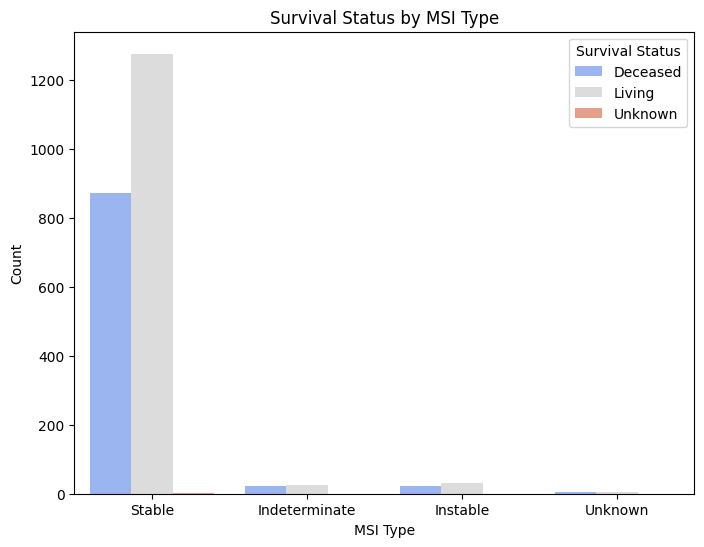

In [49]:
# MSI Type and Survival

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='MSI Type', hue='Survival Status', palette='coolwarm')
plt.title('Survival Status by MSI Type')
plt.ylabel('Count')
plt.xticks
plt.show()

We will use MSI Type, instead of MSI Score as the MSI Type is determined by a particular thresold of MSI Score.

We can observe that there are signnificantly more cases of MSI stable than Intermediate or Instable. One specific insight from this graph is that the gap between living and deceased among stable seems to be higher compared to other types.

Clinical features have given us really good insights on how these features are related to the survial rate.



Now lets look at Genomic Features such as Impact TMB Percentile, Impact TMB Score, Fraction Genome Altered, Gene Panel and Mutation Count

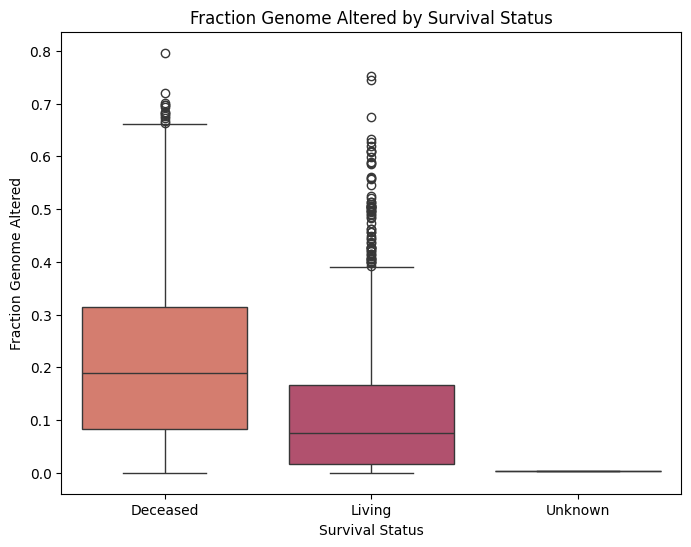

In [50]:
#Fraction Genome Altered and Survival

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Survival Status', y='Fraction Genome Altered',  hue='Survival Status', palette='flare')
plt.title('Fraction Genome Altered by Survival Status')
plt.ylabel('Fraction Genome Altered')
plt.show()


Median fraction genome altered is higher for deceased patients compared to living patients. These outliers represent patients with highly altered genomes, which may be  significant.

The higher fraction genome altered in deceased patients could indicate a correlation between genomic instability and poor survival outcomes. This aligns with findings in cancer research, where higher genomic instability is often linked to tumor aggressiveness.

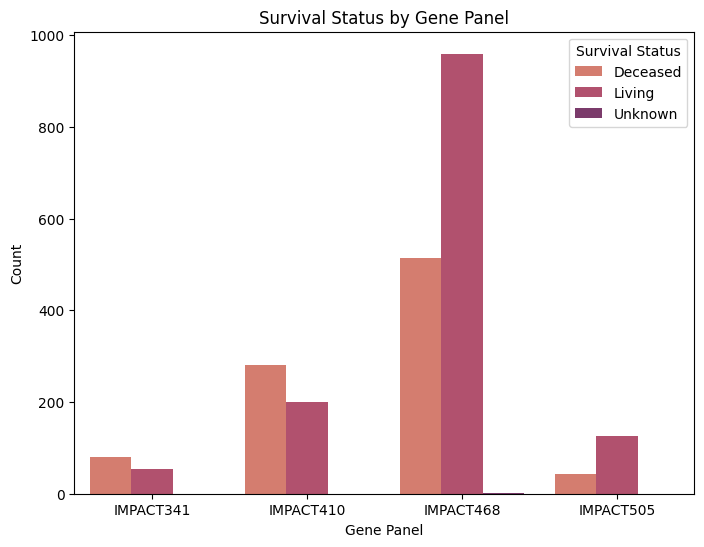

In [51]:
# MSI Type and Survival

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Gene Panel', hue='Survival Status', palette='flare')
plt.title('Survival Status by Gene Panel')
plt.ylabel('Count')
plt.xticks
plt.show()

The IMPACT468 gene panel has the highest number of patients in the "Living" compared to other panels. This could indicate that patients tested using this panel might have better survival outcomes or that it is more commonly used in patients with better prognoses.

Alternatively, this could simply reflect a higher usage of this panel in the dataset, unrelated to survival outcomes.

Lets plot a different graph to check if we can find better observations.

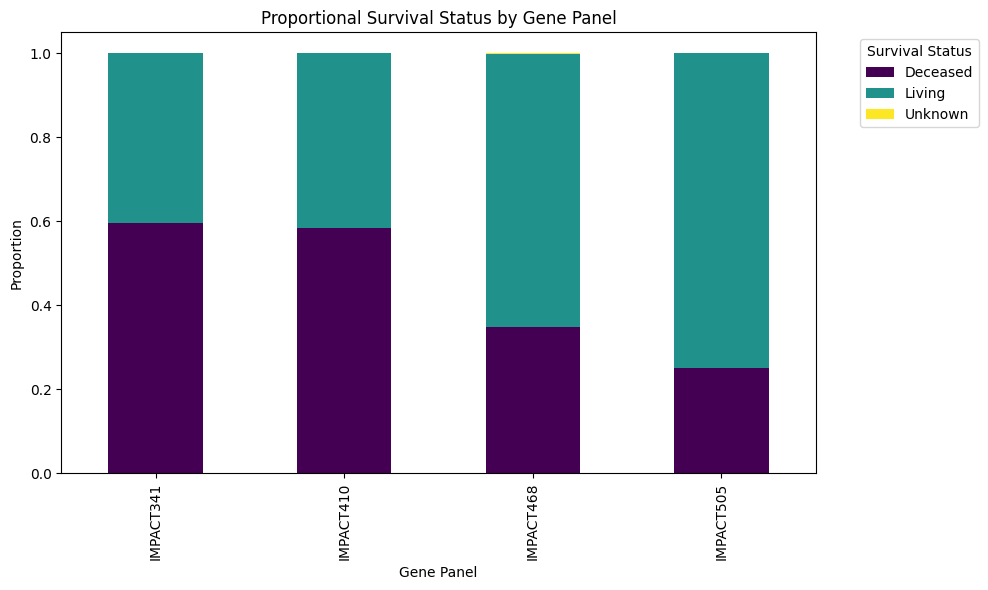

In [52]:
# Proportion of survival status by gene panel
proportions = df.groupby('Gene Panel')['Survival Status'].value_counts(normalize=True).unstack()

# Plot proportional survival status by gene panel
proportions.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Proportional Survival Status by Gene Panel')
plt.ylabel('Proportion')
plt.xlabel('Gene Panel')
plt.legend(title='Survival Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Now, We will need to test and confirm that this feature is relavent by performing somme statistical tests like chi-square test. Since the p value is l;ess than 0.05, we can conclude that this feature is significant.

In [53]:
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df['Gene Panel'], df['Survival Status'])

# Perform chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Print results
print("Chi-Square Test Results:")
print(f"Chi-Square Statistic: {chi2}")
print(f"P-Value: {p_value}")
print(f"Degrees of Freedom: {dof}")

# Interpretation
if p_value < 0.05:
    print("There is a significant association between gene panel and survival status.")
else:
    print("No significant association between gene panel and survival status.")

Chi-Square Test Results:
Chi-Square Statistic: 119.67146054097486
P-Value: 1.9101932599291103e-23
Degrees of Freedom: 6
There is a significant association between gene panel and survival status.


No lets do some analysis by adding new features for deeper exploration

In [54]:
# Bin Current Age into age groups
df['Age Group'] = pd.cut(df['Current Age'], bins=[40, 50, 60, 70, 80, 90], labels=['40-50', '51-60', '61-70', '71-80', '81-90'])

# Combine Gleason Score and Highest Stage into a composite risk factor
def calculate_risk(row):
    if row['Gleason Score'] >= 8 or row['Highest Stage'] in ['Stage 4']:
        return 'High Risk'
    elif row['Gleason Score'] in [6, 7] and row['Highest Stage'] == 'Stage 1-3':
        return 'Moderate Risk'
    else:
        return 'Low Risk'

df['Tumor Aggressiveness'] = df.apply(calculate_risk, axis=1)

This Survival status by Age group graph gives better insights than previous analysis by age. From this plot we can easily interpret that age groups 61-70 and 71-80 are more prone to prostate cancer compared to people in their early 40's and 50's.

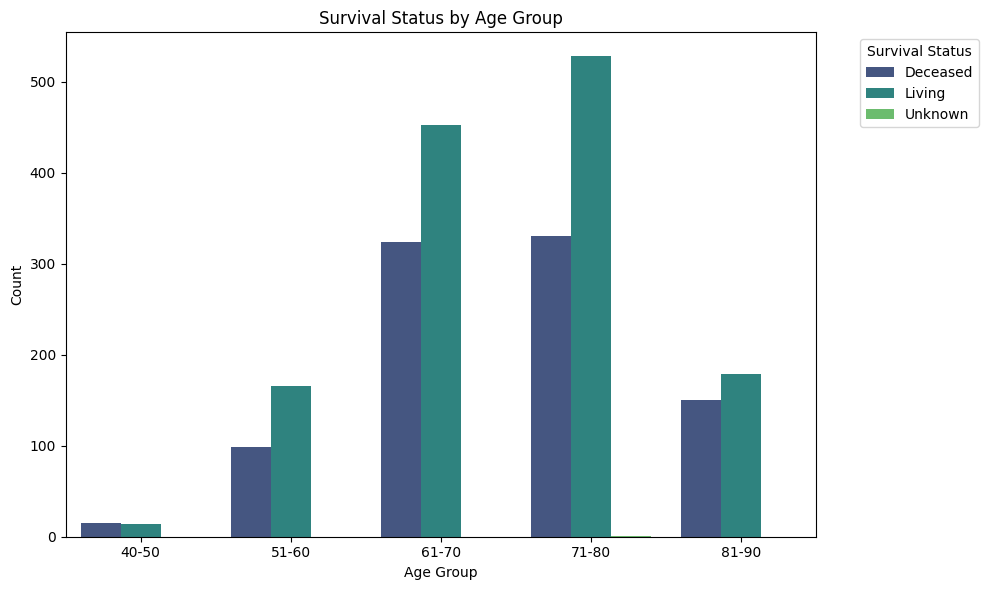

In [55]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Age Group', hue='Survival Status', palette='viridis')
plt.title('Survival Status by Age Group')
plt.ylabel('Count')
plt.xlabel('Age Group')
plt.legend(title='Survival Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Now lets see a plot of Survival status by our new feature Tumor Aggressiveness

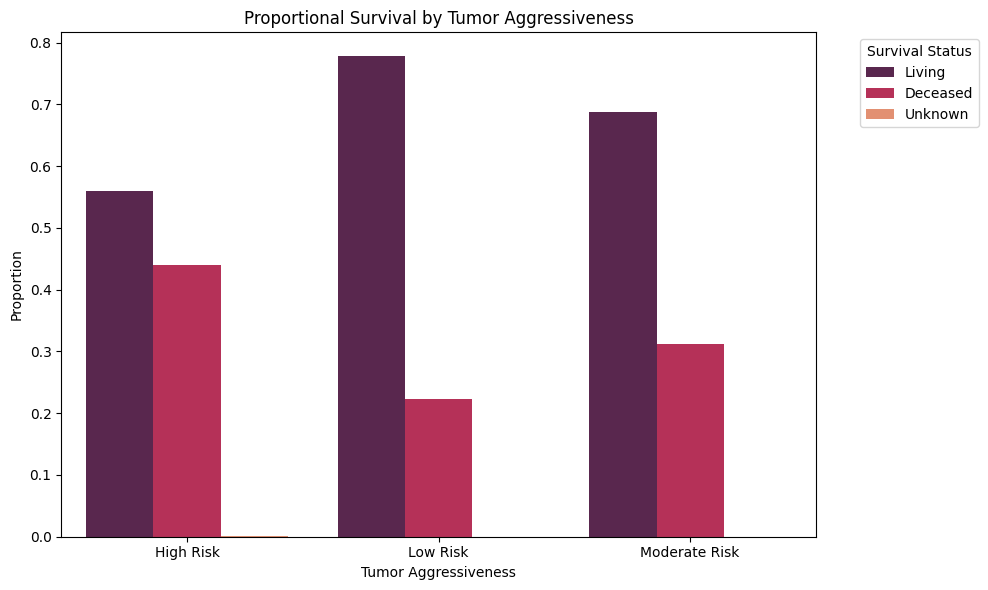

In [56]:
# Proportion of survival status within Tumor Aggressiveness categories
tumor_risk_proportion = df.groupby('Tumor Aggressiveness')['Survival Status'].value_counts(normalize=True).rename('Proportion').reset_index()

# Plot normalized barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=tumor_risk_proportion, x='Tumor Aggressiveness', y='Proportion', hue='Survival Status', palette='rocket')
plt.title('Proportional Survival by Tumor Aggressiveness')
plt.ylabel('Proportion')
plt.xlabel('Tumor Aggressiveness')
plt.legend(title='Survival Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


This graphs shows that individuals with low-risk tumors have the highest proportion of those living, followed by those with moderate-risk tumors. High-risk tumors have a relatively balanced proportion of living and deceased individuals. The proportion of deceased individuals is highest among those with high-risk tumors and lowest for low-risk cases.

This suggests that tumor aggressiveness significantly impacts survival status, with lower aggressiveness correlating with better survival outcomes.

Pairwise correlation

Pairwise correlation is a statistical tool used to measure the relationship between two variables. It quantifies how changes in one variable are associated with changes in another. It is particularly useful in EDA stage helping us identify relationships between variables, reduce redundancy, improve model performance, and check for data quality.

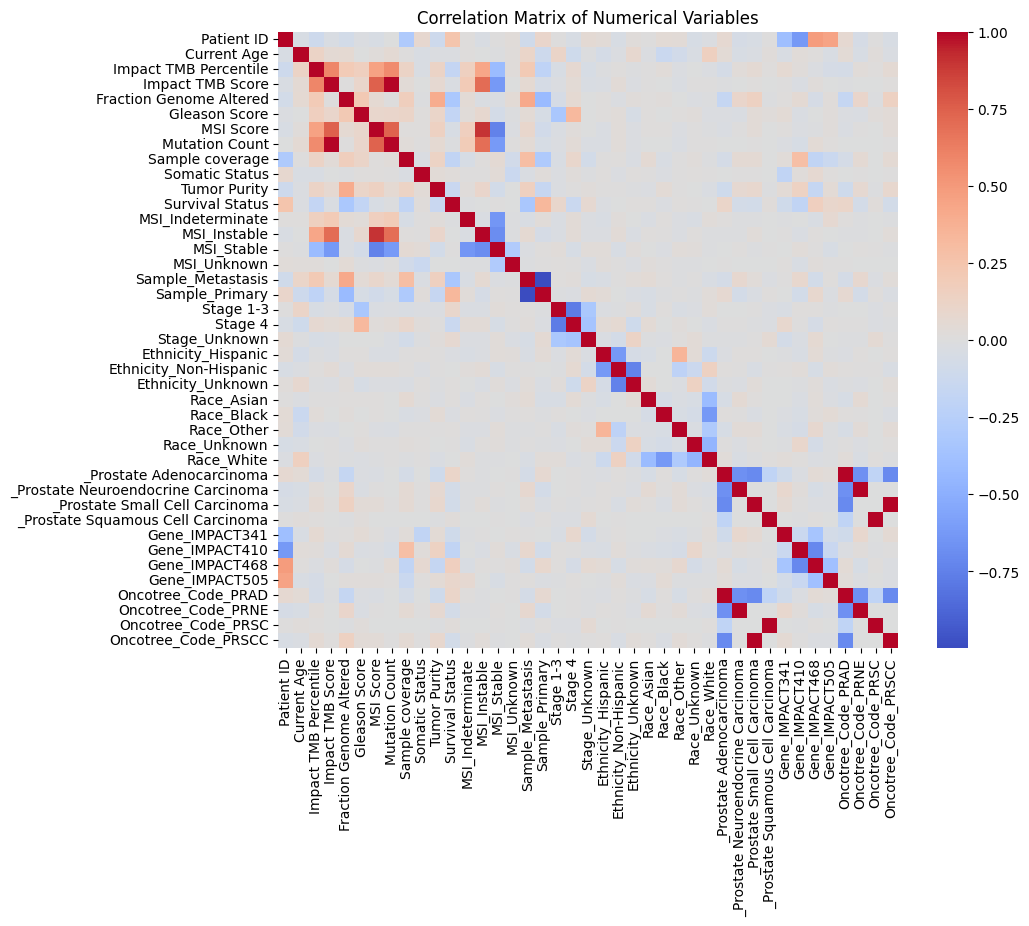

In [57]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_transformed.corr(), cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

Pairwise relationships for a subset of variables

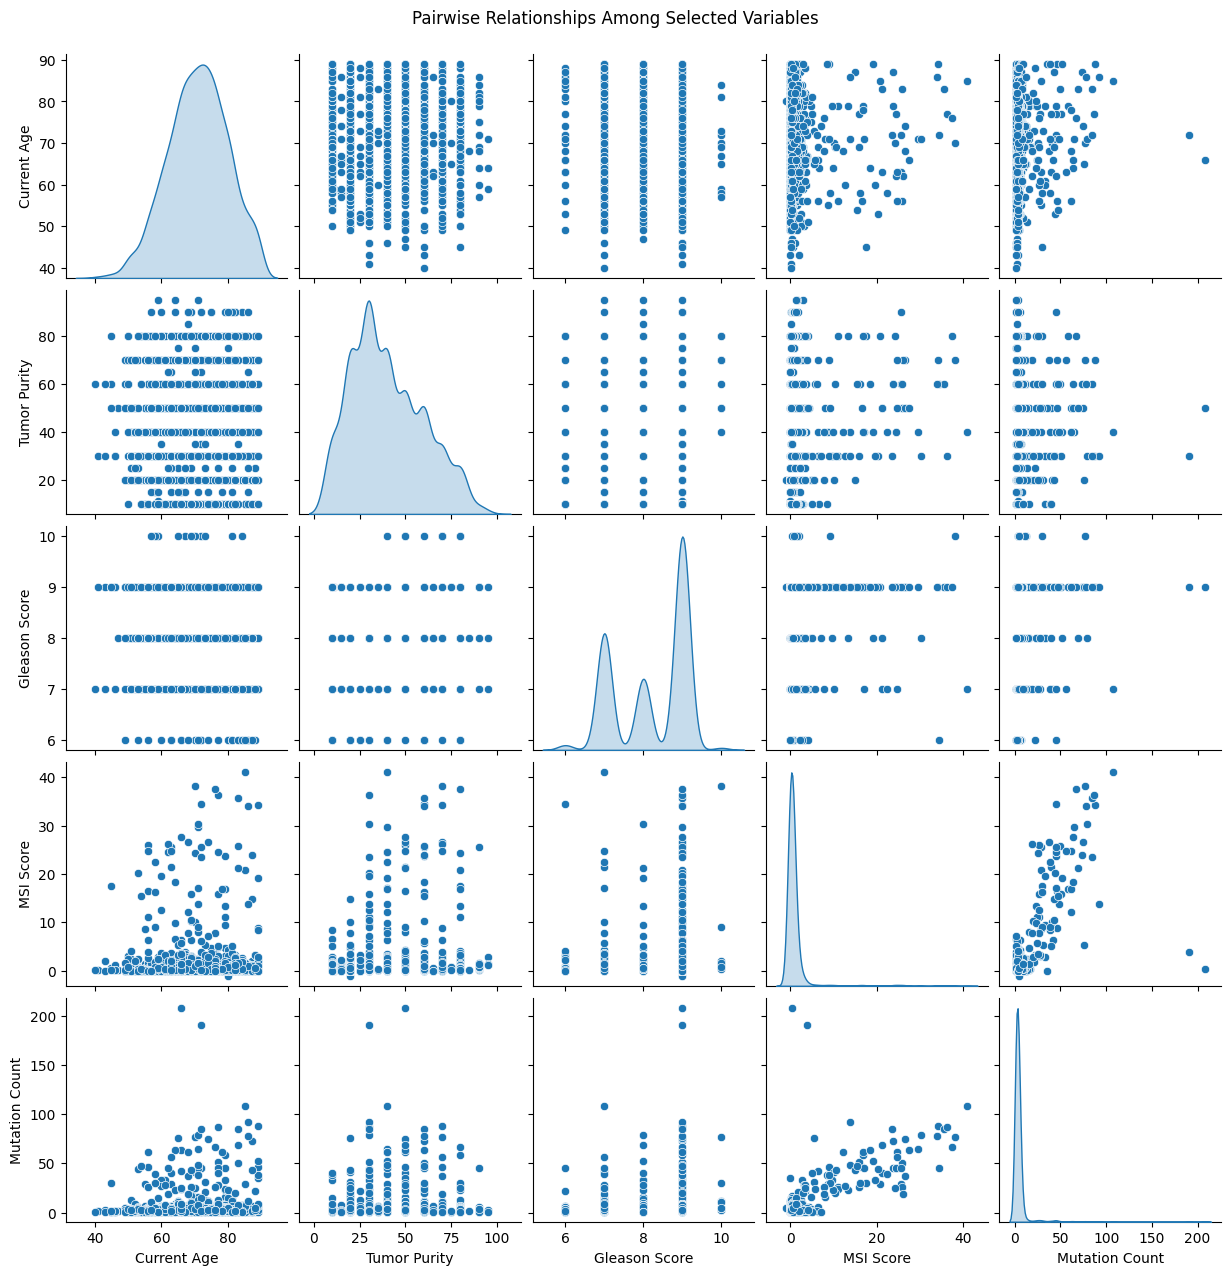

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the selected columns
selected_columns = ['Current Age', 'Tumor Purity', 'Gleason Score', 'MSI Score', 'Mutation Count']

# Ensure the columns exist in the DataFrame before plotting
if all(col in df_transformed.columns for col in selected_columns):
    sns.pairplot(df_transformed[selected_columns], diag_kind="kde")
    plt.suptitle("Pairwise Relationships Among Selected Variables", y=1.02)
    plt.show()
else:
    missing_cols = [col for col in selected_columns if col not in df_transformed.columns]
    print(f"The following columns are missing from the DataFrame: {missing_cols}")


This pair plot visualizes the relationships among the selected 5 variables: Current Age, Tumor Purity, Gleason Score, MSI Score, and Mutation Count. Diagonal histograms indicate the distribution of each variable.

Current Age shows a bell-shaped distribution centered around 60-70 years. Tumor Purity exhibits a concentrated distribution with values clustering around 40-60%. Gleason Score shows discrete clusters, due to its categorical nature. MSI Score and Mutation Count have right-skewed distributions, with a few higher outliers.

Scatter plots reveal trends among variable pairs. Mutation Count shows a positive relationship with MSI Score but no clear pattern with Tumor Purity, Current Age, or Gleason Score. Tumor Purity does not strongly correlate with Gleason Score or MSI Score. These patterns suggest that while some variables (e.g., Mutation Count and MSI Score) are interrelated, others vary independently, highlighting the complexity of these relationships.

##HYPOTHESIS TESTING AND MACHINE LEARNING

The goal of this Hypothesis testing and Machine learning step is to train a model using clinical attributes as features to predict survival outcomes, with data preprocessing and feature engineering ensuring the dataset is clean and optimized for machine learning algorithms.

The objective of this task is to predict whether a patient will survive cancer. This is a supervised learning problem that uses labeled data with known outcomes.








####Feature Selection

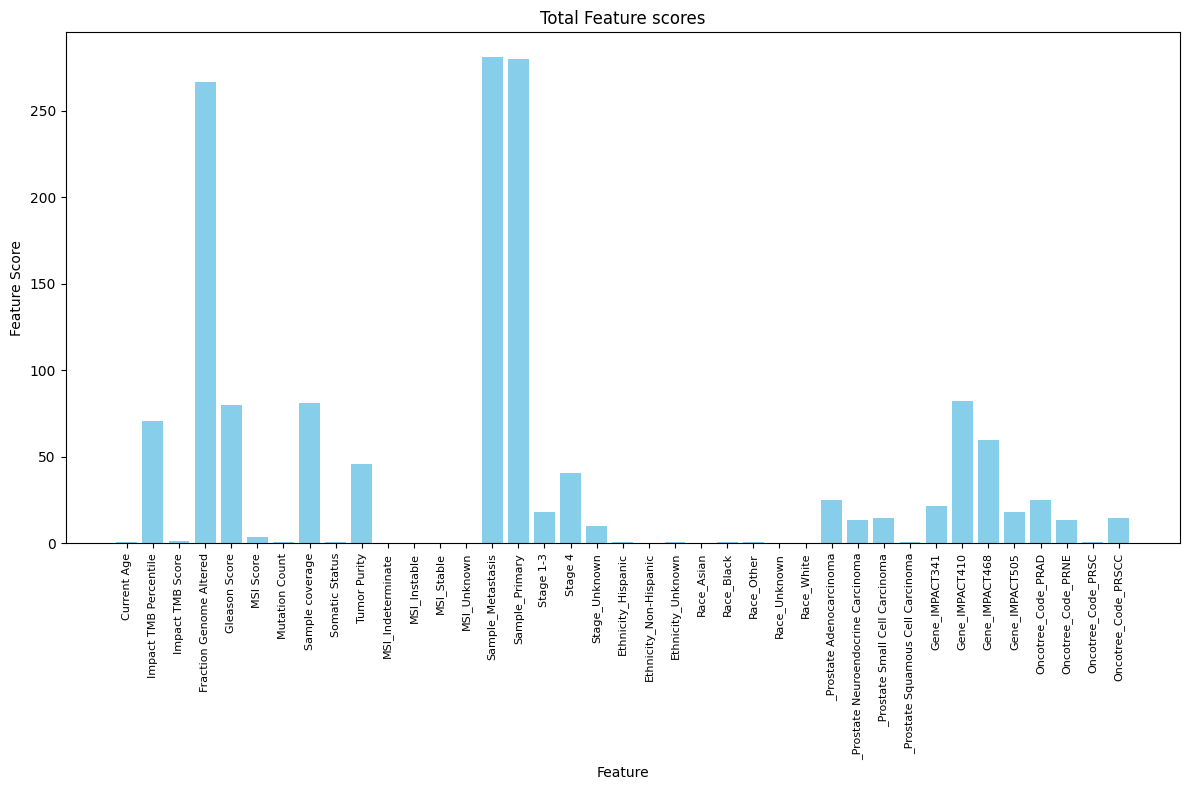

In [59]:
target = 'Survival Status'
features_to_drop = ['Patient ID', 'Survival Status']
X = df_transformed.drop(features_to_drop, axis=1)
y = df_transformed[target]
selector = SelectKBest(score_func=f_classif, k=df_transformed.shape[0])
X_selected = selector.fit_transform(X, y)

scores = selector.scores_
selected_feature_mask = selector.get_support()
selected_features = X.columns[selected_feature_mask]
plt.figure(figsize=(12, 8))
indices = np.arange(len(selected_features))
plt.bar(indices, scores[selected_feature_mask], color='skyblue')
plt.xticks(indices, selected_features, rotation=90, fontsize=8)
plt.ylabel("Feature Score")
plt.xlabel("Feature")
plt.title("Total Feature scores")
plt.tight_layout()
plt.show()

Selecting top 20 features

In [60]:
X = df_transformed.drop(features_to_drop, axis=1)
y = df_transformed[target]

selector = SelectKBest(score_func=f_classif, k=20)
X_selected = selector.fit_transform(X, y)

selected_feature_mask = selector.get_support()
selected_features = X.columns[selected_feature_mask].tolist()

print("Original dimensionality:", X.shape[1])
print("Reduced dimensionality:", X_selected.shape[1])

Original dimensionality: 39
Reduced dimensionality: 20


Data Spitting and Scaling

In [61]:
X = X[selected_features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Hyper parameter Tuning

In [62]:
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_classifier = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_classifier, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print("\nBest parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)


Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validation accuracy: 0.7039179075924764


Elavuation metrics

In [63]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

print("\nTest Set Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Set Accuracy: 0.7300884955752213

Classification Report:
              precision    recall  f1-score   support

         0.0       0.69      0.63      0.66       186
         1.0       0.76      0.80      0.78       266

    accuracy                           0.73       452
   macro avg       0.72      0.72      0.72       452
weighted avg       0.73      0.73      0.73       452



Feature importance

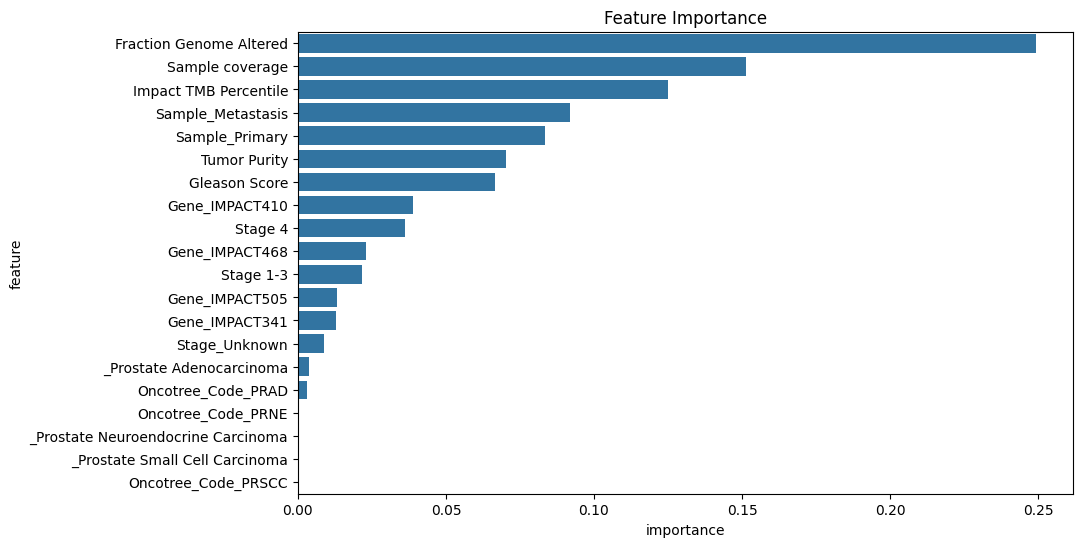

In [64]:
feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': best_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()

Confusion Matrix

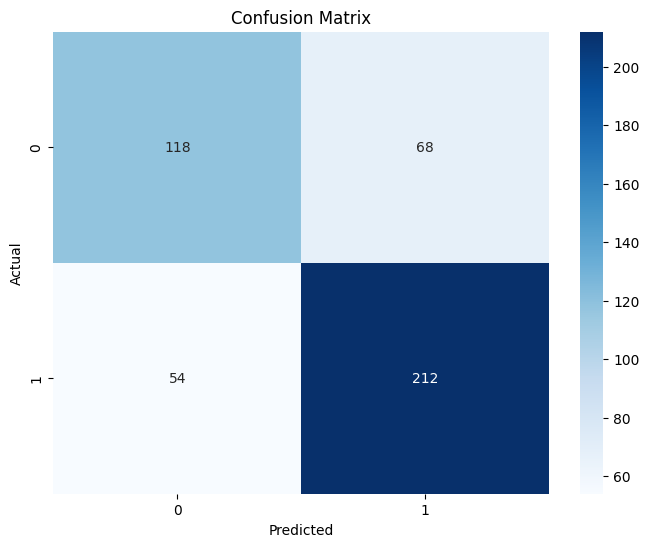

In [65]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Evaluation

Key evaluation metrics for the model include the confusion matrix, which highlights false positives and false negatives—critical insights for medical diagnostics. The ROC curve and its associated AUC measure the model's ability to distinguish between classes effectively. The precision-recall curve is particularly valuable for handling imbalanced medical data, where the minority class is often of primary interest. Additionally, cross-validation scores are used to ensure the model's stability and robustness across different data splits, providing confidence in its generalizability.

Cross-model Comparrision

Comparing between:
Random Forest
Logistic Regression
Support Vector Machine
Gradient Boosting
to see which model is able predict the output with better accuracy and less number of flase positives/negatives


----------------------------Evaluating Random Forest----------------------------------------------

Confusion Matrix for Random Forest:
 [[118  68]
 [ 54 212]]


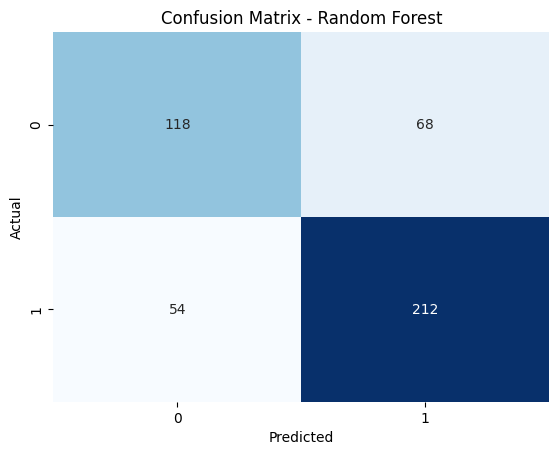

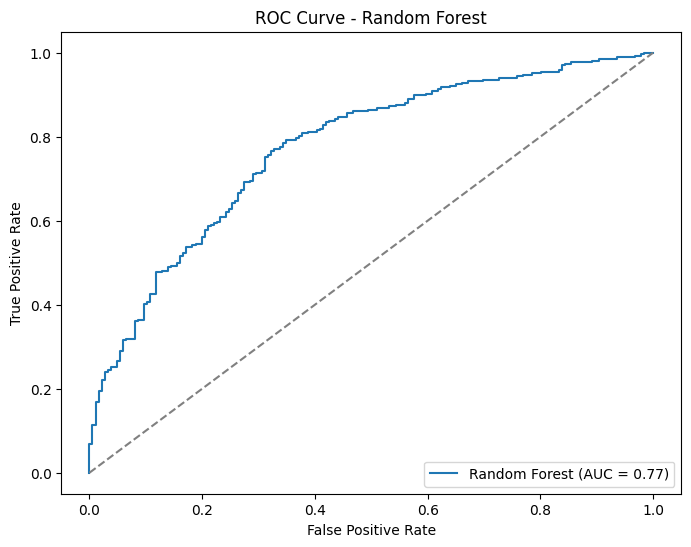

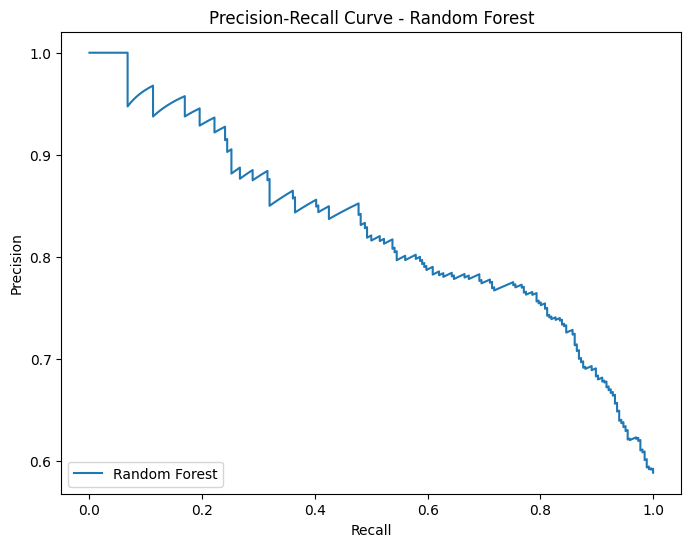


----------------------------Evaluating Logistic Regression----------------------------------------------

Confusion Matrix for Logistic Regression:
 [[109  77]
 [ 54 212]]


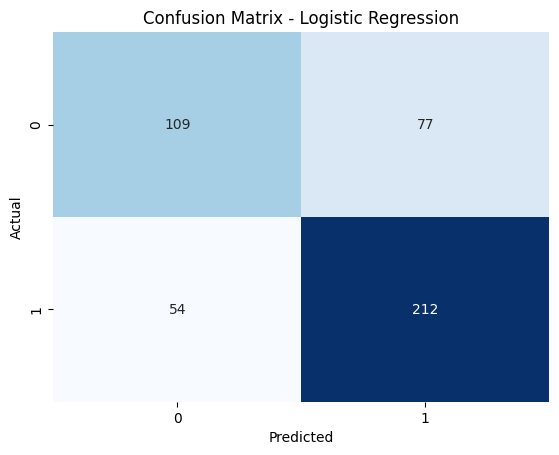

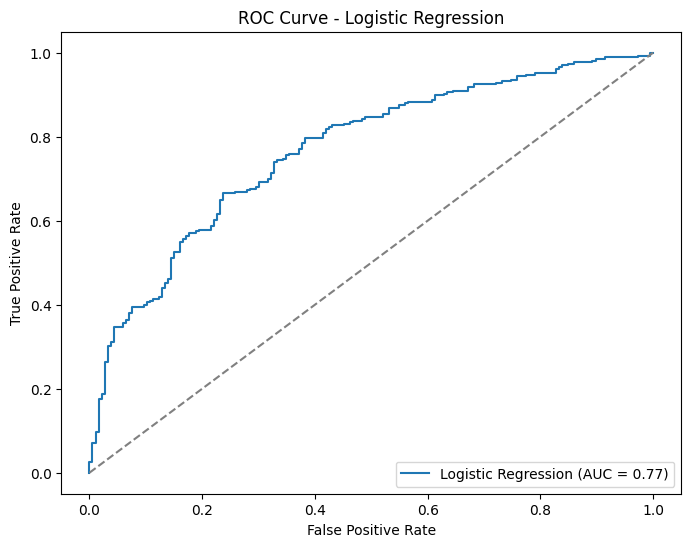

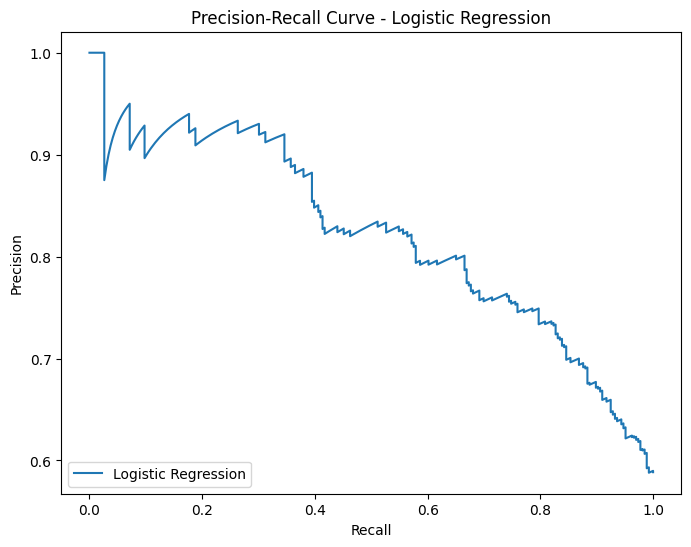


----------------------------Evaluating Support Vector Machine----------------------------------------------

Confusion Matrix for Support Vector Machine:
 [[109  77]
 [ 52 214]]


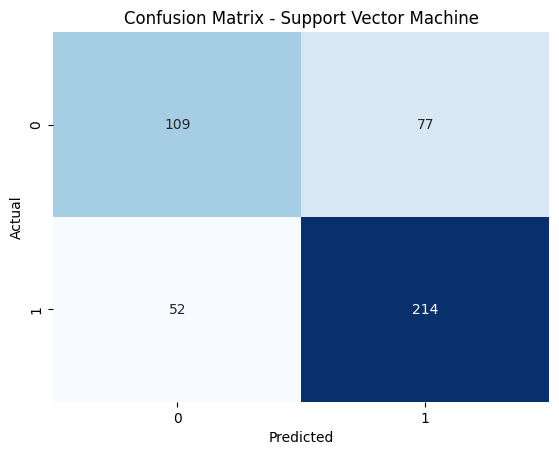

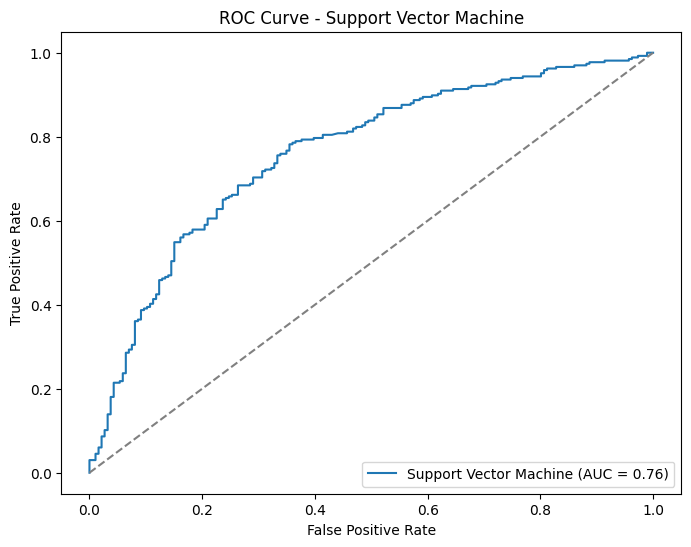

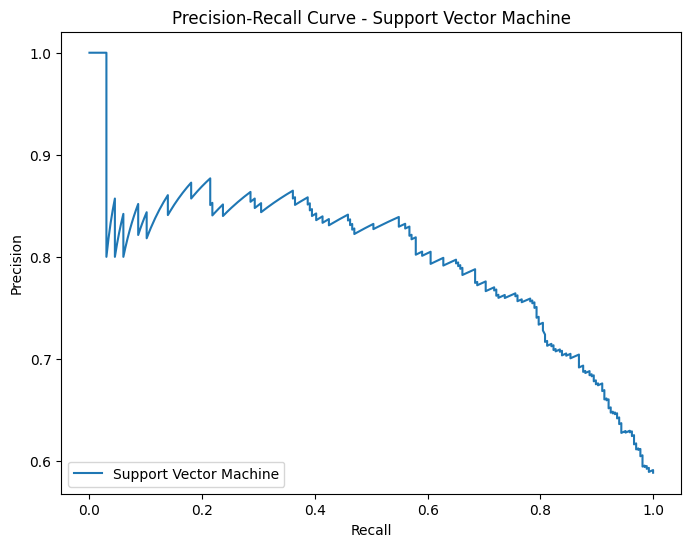


----------------------------Evaluating Gradient Boosting----------------------------------------------

Confusion Matrix for Gradient Boosting:
 [[114  72]
 [ 60 206]]


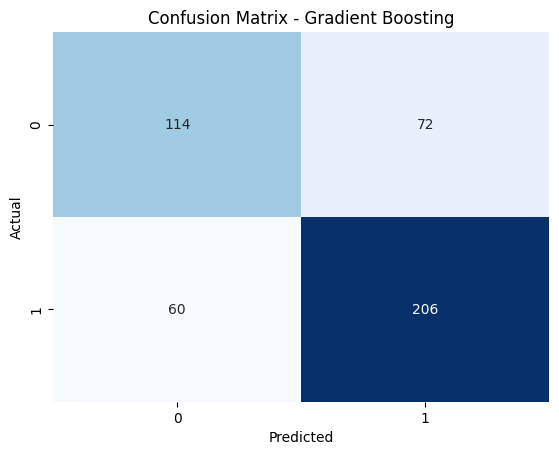

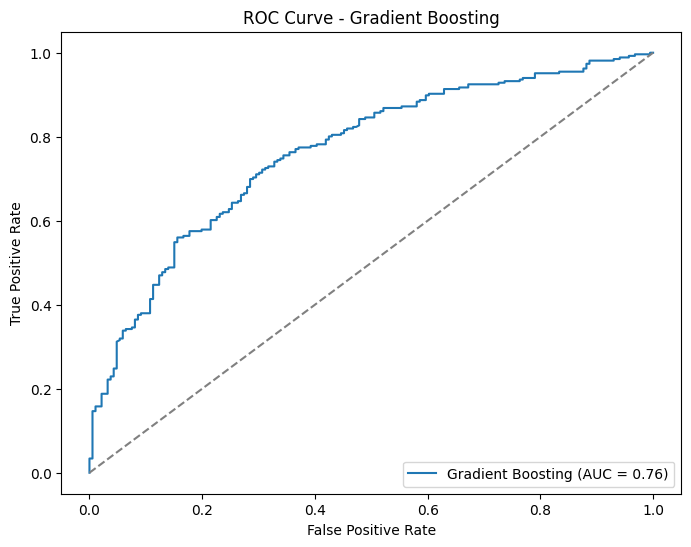

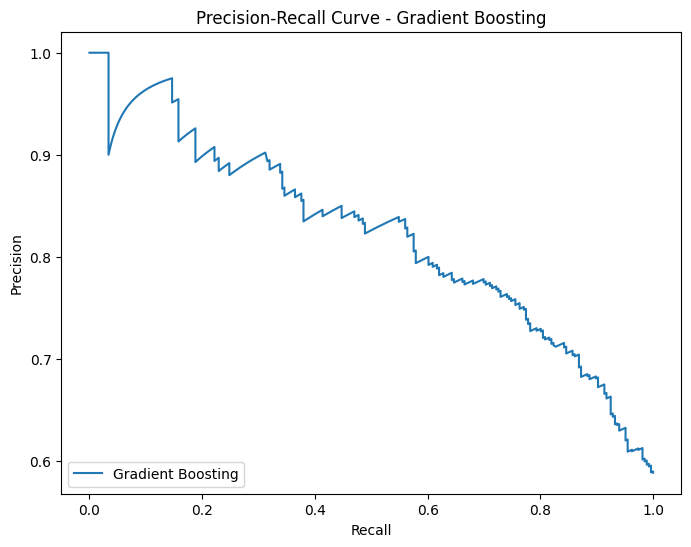


Model Performance Metrics:
                        Accuracy  \
Random Forest           0.730088   
Logistic Regression     0.710177   
Support Vector Machine  0.714602   
Gradient Boosting       0.707965   

                                                                Precision  \
Random Forest           {'0.0': {'precision': 0.686046511627907, 'reca...   
Logistic Regression     {'0.0': {'precision': 0.6687116564417178, 'rec...   
Support Vector Machine  {'0.0': {'precision': 0.6770186335403726, 'rec...   
Gradient Boosting       {'0.0': {'precision': 0.6551724137931034, 'rec...   

                                                                   Recall  \
Random Forest           {'0.0': {'precision': 0.686046511627907, 'reca...   
Logistic Regression     {'0.0': {'precision': 0.6687116564417178, 'rec...   
Support Vector Machine  {'0.0': {'precision': 0.6770186335403726, 'rec...   
Gradient Boosting       {'0.0': {'precision': 0.6551724137931034, 'rec...   

                   

In [66]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
svm_model = SVC(probability=True, random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

models = {
    'Random Forest': best_model,
    'Logistic Regression': logistic_model,
    'Support Vector Machine': svm_model,
    'Gradient Boosting': gb_model
}


def evaluate_models(models, X_train, X_test, y_train, y_test):
    results = {}
    for name, model in models.items():
        print(f"\n----------------------------Evaluating {name}----------------------------------------------\n")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

        accuracy = accuracy_score(y_test, y_pred)
        precision = classification_report(y_test, y_pred, output_dict=True)
        recall = classification_report(y_test, y_pred, output_dict=True)
        f1 = classification_report(y_test, y_pred, output_dict=True)

        cm = confusion_matrix(y_test, y_pred)
        print(f"Confusion Matrix for {name}:\n", cm)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix - {name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

        if y_prob is not None:
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            roc_auc = auc(fpr, tpr)
            plt.figure(figsize=(8, 6))
            plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
            plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC Curve - {name}')
            plt.legend(loc='lower right')
            plt.show()

        if y_prob is not None:
            precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
            plt.figure(figsize=(8, 6))
            plt.plot(recall_vals, precision_vals, label=f'{name}')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall Curve - {name}')
            plt.legend(loc='lower left')
            plt.show()

        results[name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        }

    return results

model_results = evaluate_models(models, X_train_scaled, X_test_scaled, y_train, y_test)

results_df = pd.DataFrame(model_results).T
print("\nModel Performance Metrics:")
print(results_df)

##INSIGHTS and ANALYSIS

### Summary

This report provides an overview of the performance of several classification models in predicting cancer survival. The analysis evaluates models such as Random Forest, Logistic Regression, Support Vector Machine (SVM), and Gradient Boosting, using metrics such as confusion matrices, ROC curves, precision-recall curves, and feature importance. Key insights into the trade-offs between precision, recall, sensitivity, and specificity are highlighted, along with the relative importance of features in the classification tasks.

### Insights
- Random Forest is recommended for its overall balance between precision, recall, and robustness.
- Logistic Regression can be used when simplicity and interpretability are priorities.
- Gradient Boosting or SVM can be alternatives for datasets requiring specific optimization in non-linear patterns or feature-specific importance.

#### Model Performance
- **Random Forest**:
  - Exhibited strong discriminative power with an AUC of 0.77.
  - Balanced performance between precision and recall, as indicated by the precision-recall and ROC curves.
  - Confusion matrix shows good true positive (212) and true negative (118) rates.

- **Logistic Regression**:
  - AUC of 0.77, similar to Random Forest, indicating competitive performance.
  - Precision-recall curve demonstrates stability at higher recall values, making it a strong contender for balanced scenarios.
  - Slightly lower true negatives (109) compared to Random Forest.

- **Support Vector Machine (SVM)**:
  - AUC of 0.76, slightly behind Logistic Regression and Random Forest.
  - The precision-recall curve shows faster degradation of precision at higher recall levels.
  - Confusion matrix highlights a marginal improvement in true positives (214) but fewer true negatives (109).

- **Gradient Boosting**:
  - Similar AUC to SVM at 0.76, with comparable performance in precision and recall.
  - Confusion matrix reflects a slightly higher false negative rate compared to Random Forest.


###Conclusions and Next Steps

In this part of the lifecycle we attempt to utilize our data analysis to draw actionable conclusions.

Based on observations throughout the analysis and modeling, the features such as Fraction Genome Altered , Sample Coverage, and Impact TMB Percentile are highly indicative of survival outcomes. These findings highlight the importance of tumor specific genetic metrics in predicting survival.

Overall, this analysis provides valuable insights into cancer survival prediction, offering a foundation for clinical decision-making and further research. If more resources were available, future work could explore more advanced ensemble techniques, include time-series modeling to understand temporal effects on survival.

This pipeline illustrates how a combination of data processing, exploratory data analysis, feature engineering, and machine learning can yield meaningful insights.

